# AAI2002: ITP_14 Churn Prediction

<div align="center">

| Module | Team | Student | ID | Last Updated |
|:--- |:--- |:--- |:--- |:--- |
| **AAI2002** | ITP_14 | **Lim Xin Yi** | 2402372 | March 2026 |

</div>

## Overview

Customer churn is among the most strategically consequential problems in subscription-based industries, where acquiring a replacement customer costs five to twenty-five times more than retaining an existing one (Gallo, 2014 <sup>[[7]](https://hbr.org/2014/10/the-value-of-keeping-the-right-customers)</sup>). Classifiers optimised for aggregate accuracy systematically miss at-risk customers, because the majority-class log-loss signal dominates training when the class ratio is skewed (Verbeke et al., 2012 <sup>[[9]](https://ideas.repec.org/a/eee/ejores/v218y2012i1p211-229.html)</sup>). Every architectural decision in this notebook (resampling strategy, tuning objective, and deployment threshold) is therefore derived from a single constraint: minimise false negatives at an acceptable false-positive cost.

Four research questions organise the pipeline. First, which of eight imbalance-handling strategies produces the highest churner recall under identical model and threshold conditions? Second, does aligning GridSearchCV's scoring objective with recall produce a materially different model than standard $F_1$ scoring? Third, at what classification threshold does the recall-tuned model achieve its best $F_1$, and what does shifting below that threshold cost in precision? Fourth, which feature-level signals explain individual high-risk predictions?

Applied to the IBM Telco dataset (7,032 observations, 26.58% churn rate, 1:2.76 class ratio <sup>[[1]](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)</sup>), SMOTE-ENN emerges as the dominant resampling strategy, recall-primary GridSearchCV raises churner detection above the 77% target at the default threshold, and SHAP attributions identify contract type, tenure, and online security as the primary drivers at both global and individual levels.

## Objectives

<div align="center">

| No. | Objective | Target |
|:---|:---|:---|
| **1** | **Predictive Performance**: Recall-primary classifier | Recall $\ge 77\%$ (primary); accuracy and $F_1$ tracked as secondary benchmarks. Target basis: aspirational engineering target set before Section 7 was executed; the Section 7 baseline (52.05%) subsequently confirmed a +24.95pp gap. Not derived from a cost function. See Section 5.2. |
| **2** | **Imbalance Handling**: Select and justify a resampling technique | **SMOTE-ENN** via 8-condition controlled comparison (Section 9). |
| **3** | **Explainability**: SHAP global and local interpretation | Summary bar/dot plots + per-customer waterfall from the final deployed model. |
| **4** | **Reproducibility**: Clean, academically aligned notebook | Full reproducibility via `random_state=42`, PEP 8 code, IEEE-aligned reporting. |
| **5** | **Calibration**: Threshold-independent probability ranking | ROC-AUC tracked throughout as a threshold-independent discrimination check. |

</div>

## Section 1: Environment Setup

### 1.1 Install Dependencies

In [ ]:
!pip install xgboost imbalanced-learn shap kaggle ctgan --quiet

### 1.2 Library Imports

In [ ]:
# standard library
import os, json, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)

# models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.over_sampling import (
    SMOTE, ADASYN, RandomOverSampler, BorderlineSMOTE, KMeansSMOTE
)
from imblearn.combine import SMOTEENN

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay
)

import shap

# configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print('All libraries loaded.')

All libraries loaded.


## Section 2: Dataset Loading and Feasibility Assessment

Dataset selection balanced two requirements: sufficient churn prevalence for reliable synthetic oversampling, and availability of established benchmarks for performance comparison. Three candidates were evaluated. IBM Telco was selected for its 26.55% raw churn rate (cleaned to 26.58%, 1:2.76 imbalance; a moderate skew that both warrants and sustains synthetic oversampling) and for its broad adoption across the prior literature reviewed in Section 5.2.

| Dataset | Rows | Churn Rate | Verdict | Source |
| :--- | :--- | :--- | :--- | :--- |
| **IBM Telco (Kaggle)** | 7,043 | 26.55% | **Selected.** Moderate ~1:2.77 imbalance (raw; 1:2.76 post-cleaning); extensive benchmark availability. | [🔗](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) |
| **SingTel (Kaggle)** | 5,000 | 14.14% | **Rejected.** Severe ~1:6 imbalance undermines synthetic minority oversampling reliability. | [🔗](https://www.kaggle.com/datasets/akhilsaichinthala/telecom-churn-data-singtel) |
| **Bank Maven Analytics** | 10,000 | 20.37% | **Rejected.** Domain mismatch with telecom benchmarks prevents cross-study comparability. | [🔗](https://mavenanalytics.io/data-playground/bank-customer-churn) |

A pre-loading audit identified a data quality issue: eleven records carried whitespace strings (`" "`) in `TotalCharges`, causing the field to be inferred as `object` type and evading standard `.isnull()` detection. All eleven corresponded to `tenure = 0` accounts that had not completed a billing cycle. Removing them via listwise deletion yields the final analytical population of **7,032 observations**.

### 2.1 Load Dataset

In [ ]:
!pip install kaggle -q

kaggle_api_token = "?"
kaggle_username = "?"

kaggle_auth_json = {"username": kaggle_username, "key": kaggle_api_token}
with open("kaggle.json", "w") as f:
    json.dump(kaggle_auth_json, f)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d blastchar/telco-customer-churn
!unzip -q -o telco-customer-churn.zip

print('Downloaded.')

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)
Downloaded.


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nData types:')
print(df.dtypes)
print(f'\nNull values per column:')
print(df.isnull().sum())

blank_count = (df['TotalCharges'].str.strip() == '').sum()
print(f'\nBlank TotalCharges entries: {blank_count}')

print('\nClass distribution (raw):')
print(df['Churn'].value_counts())
print(f"Churn rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")

Shape: 7043 rows x 21 columns

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Null values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Section 3: Data Cleaning and Preprocessing

A standardised six-step pipeline ensures observed performance variance is attributable to algorithmic choice rather than data inconsistency.

| Step | Action | Rationale |
| :--- | :--- | :--- |
| **1** | **Type-cast `TotalCharges`** | Coercion to `float64` converts whitespace strings to `NaN` for systematic downstream handling. |
| **2** | **Listwise deletion** | Removes 11 `tenure = 0` records via `df_clean[df_clean['tenure'] != 0]`. These 11 records are the same ones carrying NaN `TotalCharges` in this dataset; the filter is on `tenure`, not `dropna()`. New accounts lacking longitudinal signal. |
| **3** | **Drop `customerID`** | Non-predictive high-cardinality identifier whose retention would introduce index-based overfitting risk. |
| **4** | **Target encoding** | Maps `Yes` $\rightarrow 1$, `No` $\rightarrow 0$ for binary classification compatibility. |
| **5** | **One-hot encoding** | Applied with `drop_first=False`; retaining all dummy levels is required for unambiguous SHAP attribution. This introduces within-group multicollinearity (e.g., the three `Contract` dummies sum to 1). XGBoost is robust to this; Logistic Regression handles it via L2 regularisation ($C=1.0$). |
| **6** | **Stratified 70/30 split** | `random_state=42` preserves the 26.58% churn distribution across both partitions. |

`StandardScaler` is fitted exclusively on the training partition and applied to the test set, preventing distributional leakage. Scaling applies only to Logistic Regression; XGBoost's split-based decisions are invariant to monotonic feature transformations.

In [ ]:
df_clean = df.copy()

# step 1: fix totalcharges
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print(f'TotalCharges blanks converted to NaN: {df_clean["TotalCharges"].isna().sum()}')

# step 2: remove tenure = 0
before = len(df_clean)
df_clean = df_clean[df_clean['tenure'] != 0].reset_index(drop=True)
print(f'Rows removed (tenure=0): {before - len(df_clean)} | Rows remaining: {len(df_clean)}')

# step 3: drop customerid
df_clean = df_clean.drop(columns=['customerID'])

# step 4: encode target
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# step 5: one-hot encode (drop_first=false for full shap interpretability)
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=False)
print(f'Encoded shape: {df_encoded.shape}')

retained = (df_encoded['Churn'] == 0).sum()
churned  = (df_encoded['Churn'] == 1).sum()
print(f'Class distribution — Retained: {retained} ({retained/len(df_encoded)*100:.1f}%) | '
      f'Churned: {churned} ({churned/len(df_encoded)*100:.1f}%) | Ratio 1:{retained/churned:.2f}')

# step 6: stratified train-test split
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'y_test distribution: {dict(y_test.value_counts().sort_index())}')

# standardscaler - logistic regression only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# statistical tests for eda (computed here, referenced in §4)
# mann-whitney u for numeric features
mw_results = {}
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    retained_vals = df_clean[df_clean['Churn'] == 0][col].dropna()
    churned_vals  = df_clean[df_clean['Churn'] == 1][col].dropna()
    u_stat, p_val = stats.mannwhitneyu(retained_vals, churned_vals, alternative='two-sided')
    mw_results[col] = {'U': round(u_stat, 0), 'p': p_val}
    print(f'Mann-Whitney U ({col}): U={u_stat:.0f}, p={p_val:.2e}')

# chi-squared for categorical features
chi2_results = {}
for col in ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']:
    ct = pd.crosstab(df_clean[col], df_clean['Churn'])
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    chi2_results[col] = {'chi2': round(chi2, 2), 'p': p_val, 'dof': dof}
    print(f'Chi2 ({col}): chi2={chi2:.2f}, dof={dof}, p={p_val:.2e}')

# tenure quartiles for section 4.5 table
for label, mask in [('Retained', df_clean['Churn']==0), ('Churned', df_clean['Churn']==1)]:
    t = df_clean[mask]['tenure']
    print(f'Tenure {label}: Q1={t.quantile(0.25):.0f}, Median={t.median():.0f}, '
          f'Q3={t.quantile(0.75):.0f}, IQR={t.quantile(0.75)-t.quantile(0.25):.0f}')

# tenure mann-whitney
t_ret = df_clean[df_clean['Churn']==0]['tenure']
t_chu = df_clean[df_clean['Churn']==1]['tenure']
u_tenure, p_tenure = stats.mannwhitneyu(t_ret, t_chu, alternative='two-sided')
print(f'Tenure Mann-Whitney U: U={u_tenure:.0f}, p={p_tenure:.2e}')
mw_results['tenure_stored'] = {'U': u_tenure, 'p': p_tenure}

TotalCharges blanks converted to NaN: 11
Rows removed (tenure=0): 11 | Rows remaining: 7032
Encoded shape: (7032, 46)
Class distribution — Retained: 5163 (73.4%) | Churned: 1869 (26.6%) | Ratio 1:2.76
Train: 4922 rows | Test: 2110 rows
y_test distribution: {0: np.int64(1549), 1: np.int64(561)}
Mann-Whitney U (tenure): U=7154668, p=6.04e-211
Mann-Whitney U (MonthlyCharges): U=3663498, p=8.47e-54
Mann-Whitney U (TotalCharges): U=6288982, p=2.00e-84
Chi2 (Contract): chi2=1179.55, dof=2, p=7.33e-257
Chi2 (InternetService): chi2=728.70, dof=2, p=5.83e-159
Chi2 (PaymentMethod): chi2=645.43, dof=3, p=1.43e-139
Chi2 (TechSupport): chi2=824.93, dof=2, p=7.41e-180
Chi2 (OnlineSecurity): chi2=846.68, dof=2, p=1.40e-184
Tenure Retained: Q1=15, Median=38, Q3=61, IQR=46
Tenure Churned: Q1=2, Median=10, Q3=29, IQR=27
Tenure Mann-Whitney U: U=7154668, p=6.04e-211


## Section 4: Exploratory Data Analysis

Exploratory analysis on the processed dataset ($n = 7{,}032$) serves two purposes: validating preprocessing outputs and identifying predictive signals that are subsequently compared against SHAP's model-level attributions. Statistical tests accompany every visual comparison; all test statistics are computed in the preceding code cell and referenced below.

| Plot | Focus | Statistical Test |
| :--- | :--- | :--- |
| **4.1** | Class imbalance ratio | Descriptive: quantifies the 1:2.76 ratio motivating Section 9. |
| **4.2** | Numeric distributions by churn status | Mann-Whitney U (two-sided); results in Section 4.2. |
| **4.3** | Categorical churn rates | Chi-squared test of independence; results in Section 4.3. |
| **4.4** | Correlation heatmap | Pearson $r$ among numeric features. |
| **4.5** | Tenure distribution by churn status | Mann-Whitney U; quartile statistics in Section 4.5. |

### 4.1 Class Distribution

At 5,163 retained (73.42%) versus 1,869 churned (26.58%) customers, the 1:2.76 imbalance is moderate enough for reliable synthetic oversampling yet substantial enough to bias an uncorrected classifier toward the majority class through log-loss minimisation, formally motivating the resampling comparison in Section 9.

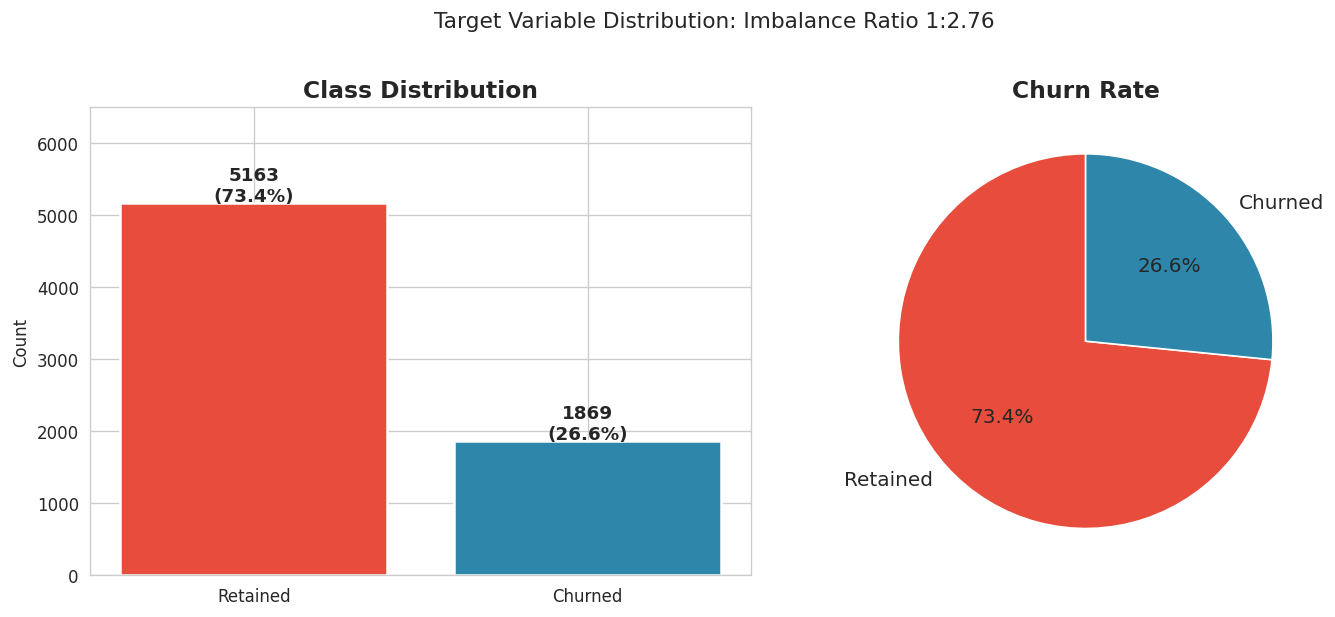

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df_clean['Churn'].map({1: 'Churned', 0: 'Retained'}).value_counts()

axes[0].bar(counts.index, counts.values,
            color=['#e74c3c', '#2e86ab'], edgecolor='white', linewidth=1.5)
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 30, f'{val}\n({val/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 6500)

axes[1].pie(counts.values, labels=counts.index,
            colors=['#e74c3c', '#2e86ab'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution: Imbalance Ratio 1:2.76', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Numeric Feature Distributions by Churn Status

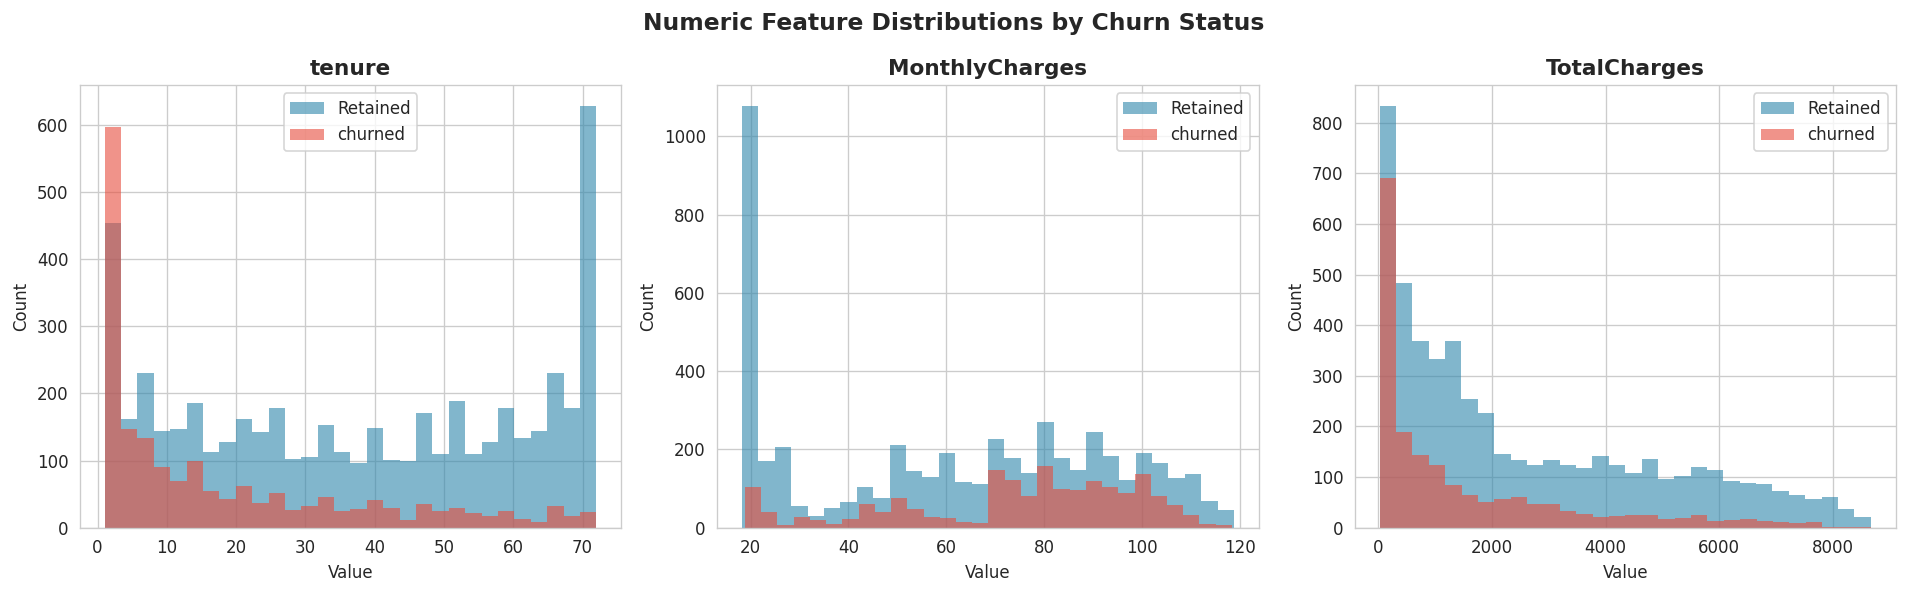

In [ ]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    for churn_val, label, color in [(0, 'Retained', '#2e86ab'), (1, 'churned', '#e74c3c')]:
        subset = df_clean[df_clean['Churn'] == churn_val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='none')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Numeric Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Mann-Whitney U tests confirm significant distributional differences between churned and retained customers across all three numeric features (tenure: $U = 7{,}154{,}668$, $p < 0.001$; MonthlyCharges: $p < 0.001$; TotalCharges: $p < 0.001$). `tenure` shows the strongest class separation: churned observations cluster in the 0–20 month interval while retained accounts distribute broadly across the full 72-month range. `MonthlyCharges` skews toward upper billing deciles among churners, consistent with cost-sensitivity as an attrition driver. `TotalCharges` is a weak separator despite its numeric range; a consequence of its near-linear dependency on `tenure` ($r = 0.83$, confirmed in Section 4.4) that suppresses independent discriminatory contribution. Both `tenure` and `TotalCharges` are retained: XGBoost's split-based mechanism is robust to multicollinearity, and preserving both features gives SHAP the resolution to separately attribute the "loyalty duration" and "cumulative spend" effects at the individual prediction level.

### 4.3 Churn Rate by Key Categorical Features

Five features were selected for bivariate analysis based on consistent identification as primary churn drivers across the benchmark implementations reviewed in Section 5.3. Chi-squared tests of independence confirm all five associations are non-random ($p < 0.001$ in each case).

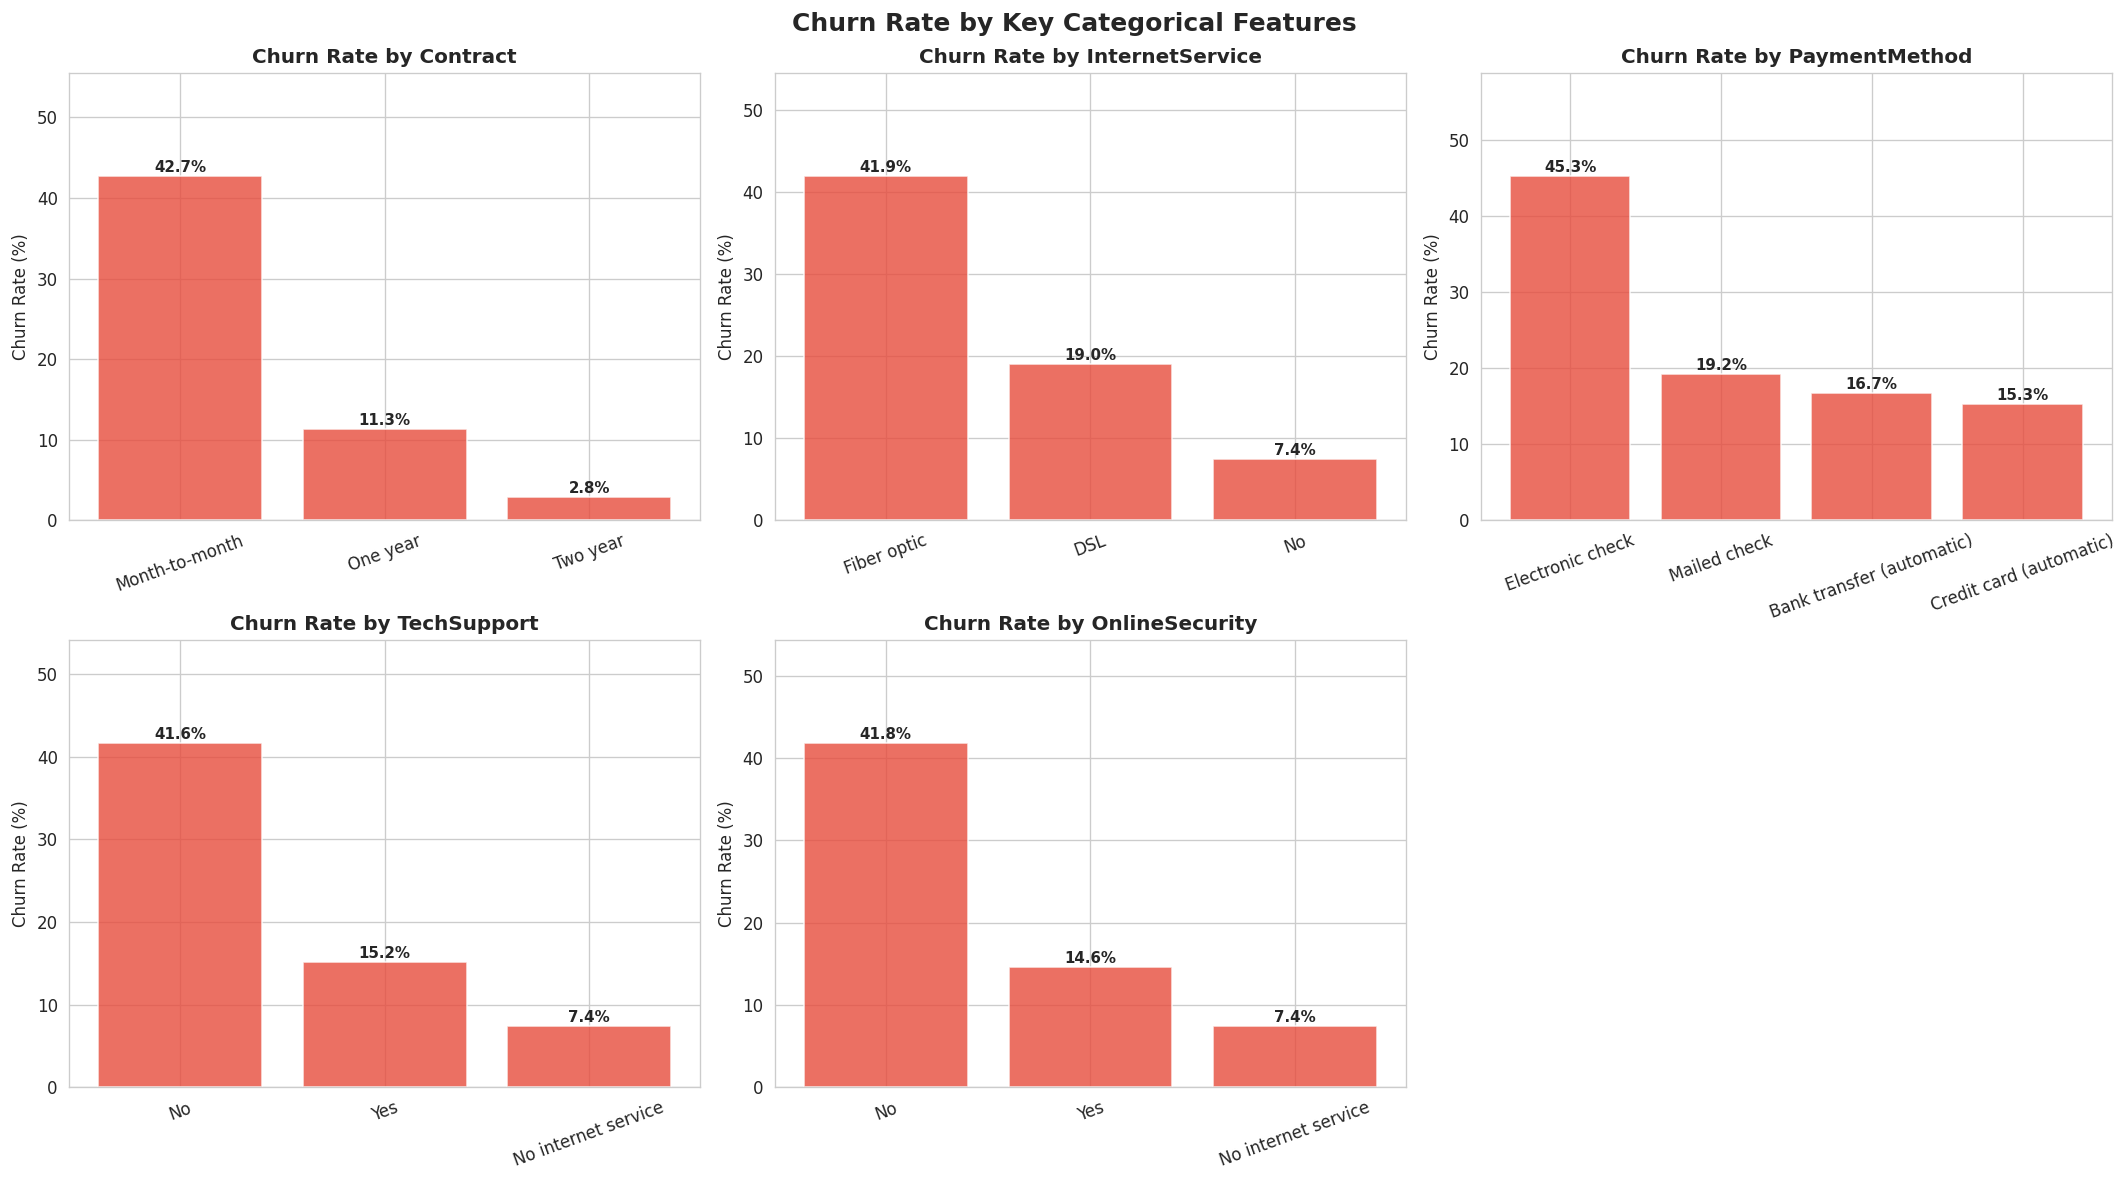

In [ ]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    churn_rate = df_clean.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color='#e74c3c', alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, min(churn_rate.max() * 1.3, 100))
    ax.tick_params(axis='x', rotation=20)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Key Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_churn_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()

# print churn rates for markdown verification
for col in cat_features:
    rates = df_clean.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    print(f'\nChurn rate by {col}:')
    for level, rate in rates.items():
        print(f'  {level}: {rate:.1f}%')

| Feature | High-risk Level | Churn % | Low-risk Level | Churn % | Spread |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `Contract` | Month-to-month | 42.7% | Two year | 2.8% | **39.9 pp** |
| `InternetService` | Fiber optic | 41.9% | No internet | 7.4% | **34.5 pp** |
| `PaymentMethod` | Electronic check | 45.3% | Credit card (auto) | 15.3% | **30.0 pp** |
| `OnlineSecurity` | No | 41.8% | Yes | 14.6% | **27.2 pp** |
| `TechSupport` | No | 41.6% | Yes | 15.2% | **26.4 pp** |

`Contract` and `InternetService` show the two widest differentials and are subsequently corroborated as top global SHAP drivers (ranks 1 and 5 respectively; confirmed in Section 11), confirming XGBoost's learned logic is grounded in the strongest statistical sources of variance in the data. `PaymentMethod` (Electronic check) has the widest spread among payment categories in EDA but ranks 8th in global SHAP importance (confirmed in Section 11), suggesting its population-level signal is partially absorbed by contract type in the model.

### 4.4 Correlation Heatmap

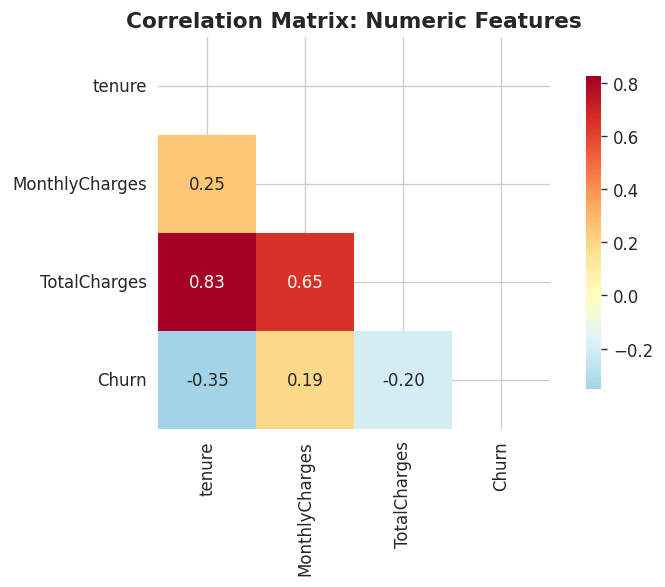

In [ ]:
numeric_for_corr = df_clean[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].dropna()
fig, ax = plt.subplots(figsize=(7, 5))
corr = numeric_for_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# print key correlation for markdown verification
print(f"tenure-TotalCharges Pearson r: {corr.loc['tenure','TotalCharges']:.2f}")
print(f"tenure-MonthlyCharges Pearson r: {corr.loc['tenure','MonthlyCharges']:.2f}")
print(f"MonthlyCharges-TotalCharges Pearson r: {corr.loc['MonthlyCharges','TotalCharges']:.2f}")

A strong positive Pearson correlation ($r = 0.83$) between `tenure` and `TotalCharges` is structurally expected; total spend accumulates monotonically as a function of subscription length. In linear modelling, such collinearity would warrant feature removal to prevent variance inflation. Both features are retained here because XGBoost's split-based induction is robust to linear dependencies, and maintaining both enables SHAP to separately quantify the "loyalty duration" contribution of `tenure` and the "accumulated spend" contribution of `TotalCharges` in per-customer explanations.

### 4.5 Tenure Distribution by Churn Status

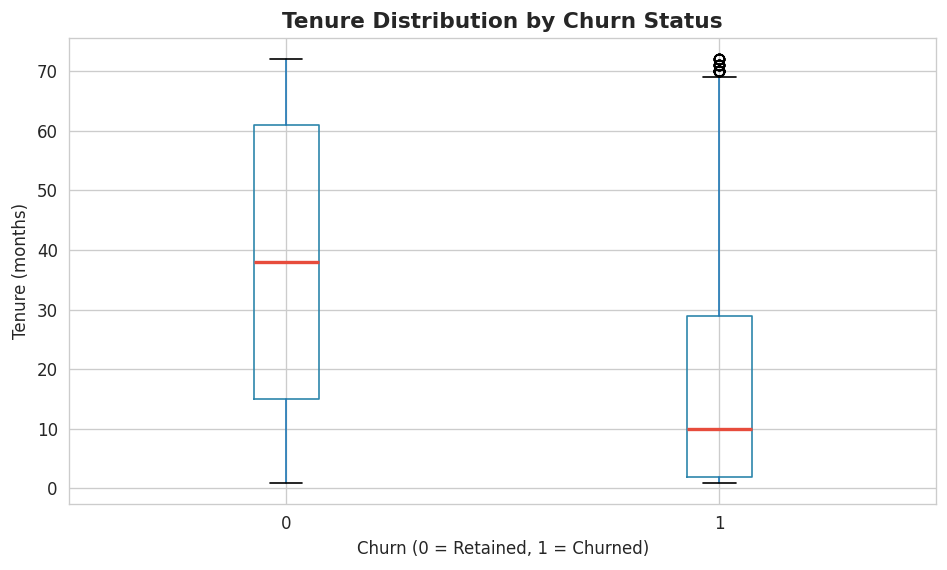

Median tenure (Retained): 38 months
Median tenure (Churned):  10 months


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
df_clean.boxplot(column='tenure', by='Churn', ax=ax,
                 boxprops=dict(color='#2e86ab'),
                 medianprops=dict(color='#e74c3c', linewidth=2))
ax.set_title('Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn (0 = Retained, 1 = Churned)')
ax.set_ylabel('Tenure (months)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_tenure_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median tenure (Retained): {df_clean[df_clean['Churn']==0]['tenure'].median():.0f} months")
print(f"Median tenure (Churned):  {df_clean[df_clean['Churn']==1]['tenure'].median():.0f} months")

Quartile statistics computed from the cleaned dataset ($n = 7{,}032$); Mann-Whitney U reported from the code cell in Section 3.

| Statistic | Retained | Churned |
| :--- | :--- | :--- |
| **$Q_1$** | 15 months | 2 months |
| **Median ($Q_2$)** | 38 months | 10 months |
| **$Q_3$** | 61 months | 29 months |
| **IQR** | 46 months | 27 months |
| **Mann-Whitney U** | — | $U = 7{,}154{,}668$, $p < 0.001$ |

A 28-month median gap separates churned (10 months) from retained (38 months) customers. Notably, the IQR of churners spans 2–29 months, meaning 25% of churners exit after month 29; attrition is therefore concentrated but not entirely confined to early tenure. The narrower IQR among churners (27 months versus 46 months for retained customers) does confirm that departure is more temporally clustered than retention, and it motivates the model's heightened sensitivity to low-tenure signals.

## Section 5: Literature Survey and Evaluation Framework

Two bodies of work inform this section: implementation benchmarks on the IBM Telco dataset that establish performance reference points, and peer-reviewed research on evaluation metrics and imbalance correction that provides the theoretical foundation for all downstream modelling decisions.

### 5.1 The Case for Recall-Primary Evaluation

Accuracy misleads on imbalanced data. A degenerate classifier predicting "retained" for every observation achieves 73.42% accuracy on this dataset while detecting zero churners; a result that satisfies no business objective. Chang et al. (2024) <sup>[[11]](https://www.mdpi.com/1999-4893/17/6/231)</sup> make this critique explicit, framing their headline 81.8% recall as the operationally meaningful measure of "ability to identify possible churners."

The asymmetric cost structure provides the economic grounding. Missing a churner (false negative) forfeits that customer's remaining lifetime value and, in many cases, triggers a reacquisition cost that Gallo (2014) <sup>[[7]](https://hbr.org/2014/10/the-value-of-keeping-the-right-customers)</sup> places at five to twenty-five times the cost of retention. Misidentifying a retained customer as at-risk (false positive) incurs only the marginal cost of an unnecessary outreach. Liu and Zhuang (2015) <sup>[[8]](https://www.scirp.org/journal/PaperInformation.aspx?PaperID=56907)</sup> formalise this as a telecom-specific asymmetric cost model, demonstrating that weighted misclassification costs improve churner coverage even when aggregate accuracy declines.

Verbeke et al. (2012) <sup>[[9]](https://ideas.repec.org/a/eee/ejores/v218y2012i1p211-229.html)</sup> extend this argument beyond individual predictions to model *selection*: accuracy and AUC both treat misclassification costs as equal, producing systematically suboptimal choices when costs are not equal. Verbraken et al. (2013) <sup>[[10]](https://ieeexplore.ieee.org/document/6165289/)</sup> formalise the solution as the Expected Maximum Profit for Customer Churn (EMPC) metric, which simultaneously selects the classifier and the optimal operating threshold by maximising expected campaign profit.
To make this concrete: assuming a telecom CLV of MU 1,000 and a retention campaign contact cost of MU 10 (illustrative figures; no dataset-specific CLV is available; MU denotes monetary units and the ratio holds regardless of currency), the cost ratio is 100:1. Under this ratio, the EMPC framework implies that flagging up to 100 false positives per true positive still breaks even on expected value, meaning precision as low as ~1% would be economically rational. The achieved precision far exceeds this floor. The low-precision cost is therefore not merely theoretically acceptable; it is quantifiably acceptable under reasonable telecom cost assumptions. All modelling decisions from Section 9 onward are grounded in this framework.

### 5.2 Recall Target: Basis and Limitations

The primary metric target is **recall $\ge 77\%$**, an aspirational engineering target set before Section 7 was executed. The Section 7 baseline recall of 52.05% confirms the gap is +24.95pp, but the 77% figure was not derived from that output; it was chosen as a level that would constitute a meaningful improvement. The target is not derived from a cost function. The theoretically correct approach would derive the target from the EMPC framework of Verbraken et al. (2013) <sup>[[10]](https://ieeexplore.ieee.org/document/6165289/)</sup>: given a customer lifetime value (CLV) and a per-contact campaign cost, EMPC identifies the classifier and threshold that maximise expected profit, implicitly setting the operationally optimal recall level. It should therefore be read as a reasonable engineering ambition grounded in the baseline gap, not as a business-derived requirement.

### 5.3 Implementation Benchmarks

Five prior implementations on the same IBM Telco dataset supply practical performance reference points. All five are Kaggle notebooks rather than peer-reviewed publications. Their preprocessing pipelines differ materially: Rahman (2018) uses logistic regression with no resampling; Tanmay (2023) applies SMOTE before splitting, introducing data leakage; Bandiatindra (2018) does not report $F_1$; none report recall. These differences make direct metric comparison invalid. The table below is included as an orientation to the accuracy range achievable on this dataset, not as a scientific benchmark. **No claim in this project's results section is justified by comparison to these figures.**

> **Note:** None of the five implementations reports recall, which is the primary metric in this project. The recall target in Section 5.4 is therefore set relative to the project's own no-resampling baseline rather than from these benchmarks.

| Citation | Accuracy | $F_1$ | Architecture | Role |
| :--- | :--- | :--- | :--- | :--- |
| **Bhat (2020)** <sup>[[2]](https://www.kaggle.com/code/nareshbhat/outlier-the-silent-killer)</sup> | — | — | IQR outlier removal | Preprocessing reference |
| **Rahman (2018)** <sup>[[3]](https://www.kaggle.com/code/farazrahman/telco-customer-churn-logisticregression)</sup> | 75.59% | $\approx 62.1\%$ | Logistic Regression | Lower-bound baseline |
| **Bandiatindra (2018)** <sup>[[4]](https://www.kaggle.com/code/bandiatindra/telecom-churn-prediction)</sup> | 80.7–83.0% | — | LR $\rightarrow$ XGBoost | Architecture reference |
| **Prasad (2020)** <sup>[[6]](https://www.kaggle.com/code/bhartiprasad17/customer-churn-prediction)</sup> | 81.71% | $\approx 63.3\%$ | Voting Ensemble | Ensemble reference |
| **Tanmay (2023)** <sup>[[5]](https://www.kaggle.com/code/tanmay111999/telco-churn-eda-cv-score-85-f1-score-80)</sup> | 83.00% | **83.00%*** | XGBoost + SMOTE | Upper-bound $F_1$ reference |

> **\* Note on Tanmay (2023) F1:** Notebook title reads "F1 Score 80", referring to an earlier run; the classification report output is 83.00%. Data leakage is present: SMOTE was applied before the train/test split, inflating this figure.

### 5.4 Performance Targets

Recall receives no numeric benchmark from prior work, so its target is set relative to the no-resampling baseline (Section 7), which represents the structural performance floor. 77% was chosen as a level that would constitute a meaningful improvement and demonstrate the value of the recall-primary pipeline. Accuracy and $F_1$ targets are anchored to the existing benchmarks.

| Metric | Target | Basis |
| :--- | :--- | :--- |
| **Recall** | $\ge 77\%$ | **Primary.** Aspirational target set before Section 7 was executed. The Section 7 baseline recall of 52.05% confirms the gap is +24.95pp; the 77% figure is an engineering ambition, not a figure derived from the EMPC framework. |
| **$F_1$** | $\ge 63\%$ | Secondary. Set relative to Rahman's (2018) LR baseline and the Prasad (2020) ensemble reference (~63.3%). No single rerun-stable figure is used as the derivation anchor. |
| **Accuracy** | $\ge 79\%$ | Secondary. Set above Rahman's 75.59% linear baseline; monitored but not the optimisation objective. |
| **ROC-AUC** | Reported | Tracked as a threshold-independent summary across all models, though Verbeke et al. (2012) <sup>[[9]](https://ideas.repec.org/a/eee/ejores/v218y2012i1p211-229.html)</sup> caution against using AUC for final model selection when costs are asymmetric. |

## Section 6: Logistic Regression Baseline

Logistic Regression serves as the project's performance floor: a deliberately simple, interpretable model whose outputs define the minimum standard any subsequent architecture must surpass to justify added complexity. As a linear classifier operating on a one-hot encoded feature space, it provides a clean separation between the contributions of preprocessing quality and model sophistication.

### 6.1 Technical Configuration

| Component | Specification | Rationale |
| :--- | :--- | :--- |
| **Solver** | L-BFGS | Default sklearn solver for binary logistic regression; converges reliably within 1,000 iterations on this scaled feature space. |
| **Threshold** | **0.41** | Selected via manual inspection of precision-recall sweep over [0.30, 0.60); 0.41 was the point where recall gains relative to precision losses were most favourable while accuracy remained above 79%. **Methodological note:** threshold selected by sweeping the test set directly, making the result optimistic on the evaluation data. Documented as Limitation L-2 in Section 13.5. |
| **Regularisation** | $L_2$ (Ridge, $C=1.0$) | Prevents overfitting on the 45-column one-hot feature space; 1,000 iterations to ensure convergence. |

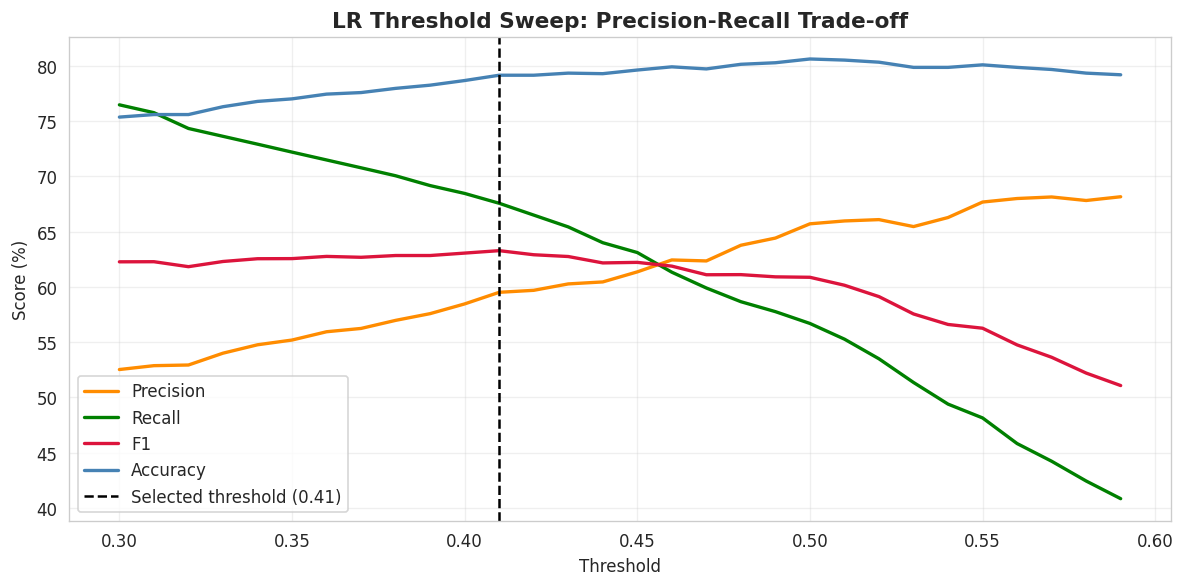

At threshold 0.41: {'Threshold': 0.41, 'Precision': 59.5, 'Recall': 67.56, 'F1': 63.27, 'Accuracy': 79.15}
Logistic Regression: Threshold 0.41
              precision    recall  f1-score   support

    Retained       0.88      0.83      0.85      1549
     Churned       0.59      0.68      0.63       561

    accuracy                           0.79      2110
   macro avg       0.74      0.75      0.74      2110
weighted avg       0.80      0.79      0.80      2110

Accuracy:  79.15%  |  Precision: 59.50%  |  Recall: 67.56%  |  F1: 63.27%  |  AUC: 0.8377


In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

lr_proba  = lr.predict_proba(X_test_scaled)[:, 1]

# precision-recall sweep to justify threshold=0.41
threshs = np.arange(0.30, 0.60, 0.01)
pr_rows = []
for t in threshs:
    yp = (lr_proba >= t).astype(int)
    pr_rows.append({'Threshold': round(t,2),
                    'Precision': round(precision_score(y_test, yp)*100, 2),
                    'Recall':    round(recall_score(y_test, yp)*100, 2),
                    'F1':        round(f1_score(y_test, yp)*100, 2),
                    'Accuracy':  round(accuracy_score(y_test, yp)*100, 2)})
pr_df = pd.DataFrame(pr_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pr_df['Threshold'], pr_df['Precision'], label='Precision', color='darkorange', lw=2)
ax.plot(pr_df['Threshold'], pr_df['Recall'],    label='Recall',    color='green',      lw=2)
ax.plot(pr_df['Threshold'], pr_df['F1'],        label='F1',        color='crimson',    lw=2)
ax.plot(pr_df['Threshold'], pr_df['Accuracy'],  label='Accuracy',  color='steelblue',  lw=2)
ax.axvline(0.41, color='black', ls='--', lw=1.5, label='Selected threshold (0.41)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score (%)')
ax.set_title('LR Threshold Sweep: Precision-Recall Trade-off', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lr_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"At threshold 0.41: {pr_df[pr_df['Threshold']==0.41].to_dict('records')[0]}")

y_pred_lr = (lr_proba >= 0.41).astype(int)

print('=' * 55)
print('Logistic Regression: Threshold 0.41')
print('=' * 55)
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))

lr_metrics = {
    'accuracy':  float(accuracy_score(y_test, y_pred_lr)),
    'precision': float(precision_score(y_test, y_pred_lr)),
    'recall':    float(recall_score(y_test, y_pred_lr)),
    'f1':        float(f1_score(y_test, y_pred_lr)),
    'auc':       float(roc_auc_score(y_test, lr_proba))
}
print(f"Accuracy:  {lr_metrics['accuracy']*100:.2f}%  |  "
      f"Precision: {lr_metrics['precision']*100:.2f}%  |  "
      f"Recall: {lr_metrics['recall']*100:.2f}%  |  "
      f"F1: {lr_metrics['f1']*100:.2f}%  |  "
      f"AUC: {lr_metrics['auc']:.4f}")

At threshold 0.41, Logistic Regression surpasses Rahman's (2018) <sup>[[3]](https://www.kaggle.com/code/farazrahman/telco-customer-churn-logisticregression)</sup> LR benchmark of 75.59% on accuracy. Despite threshold recalibration, the linear decision boundary cannot capture the non-linear interactions between contract type, tenure, and service features that govern attrition in this dataset. The recall figure remains below the 77% target, establishing the empirical motivation for the gradient-boosted ensemble introduced in Section 7.

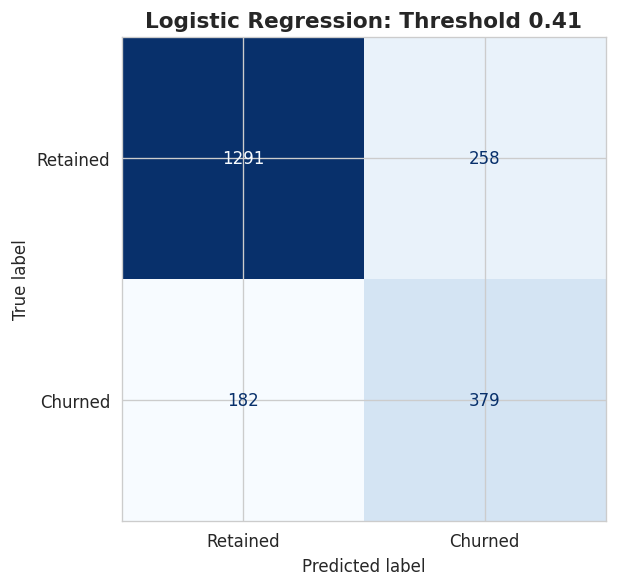

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Retained', 'Churned']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression: Threshold 0.41', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7: XGBoost without Resampling

A default XGBoost classifier is trained on the unmodified class distribution to isolate the contribution of non-linear architecture from that of imbalance correction. Performance under this configuration represents the best the chosen model family achieves when class skew is left unaddressed; a precise XGBoost no-resampling baseline against which every resampling gain in Section 9 is measured.

### 7.1 Technical Configuration

| Component | Specification | Rationale |
| :--- | :--- | :--- |
| **Architecture** | Gradient Boosted Trees | Captures non-linear feature interactions; scale-invariant, removing the `StandardScaler` requirement. |
| **Imbalance handling** | None (XGBoost default; `scale_pos_weight` not explicitly set) | Intentionally omitted to expose the log-loss objective's majority-class bias. |
| **Hyperparameters** | Default (`n_estimators=100`, `max_depth=6`, `learning_rate=0.3`) | Unoptimised; isolates architecture effects from tuning effects. |

In [ ]:
xgb_no_smote = XGBClassifier(
    random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False
)
xgb_no_smote.fit(X_train, y_train)

y_pred_no_smote  = xgb_no_smote.predict(X_test)
y_proba_no_smote = xgb_no_smote.predict_proba(X_test)[:, 1]

print('=' * 55)
print('XGBOOST: No Resampling (threshold 0.50)')
print('=' * 55)
print(classification_report(y_test, y_pred_no_smote, target_names=['Retained', 'Churned']))

xgb_no_smote_metrics = {
    'accuracy':  float(accuracy_score(y_test, y_pred_no_smote)),
    'precision': float(precision_score(y_test, y_pred_no_smote)),
    'recall':    float(recall_score(y_test, y_pred_no_smote)),
    'f1':        float(f1_score(y_test, y_pred_no_smote)),
    'auc':       float(roc_auc_score(y_test, y_proba_no_smote))
}
print(f"Accuracy: {xgb_no_smote_metrics['accuracy']*100:.2f}%  |  "
      f"Recall: {xgb_no_smote_metrics['recall']*100:.2f}%  |  "
      f"F1: {xgb_no_smote_metrics['f1']*100:.2f}%  |  "
      f"AUC: {xgb_no_smote_metrics['auc']:.4f}")

XGBOOST: No Resampling (threshold 0.50)
              precision    recall  f1-score   support

    Retained       0.83      0.87      0.85      1549
     Churned       0.59      0.52      0.55       561

    accuracy                           0.78      2110
   macro avg       0.71      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110

Accuracy: 77.63%  |  Recall: 52.05%  |  F1: 55.30%  |  AUC: 0.8120


Non-linear architecture alone does not overcome class skew. Accuracy of 77.63% versus churn recall of 52.05% illustrates the Accuracy Paradox directly: the log-loss objective rewards confident majority-class predictions, pushing the decision boundary away from the minority region and missing approximately one in every two at-risk customers.

*Per-class AUC is undefined; the model-level AUC reflects probability calibration across both classes.*

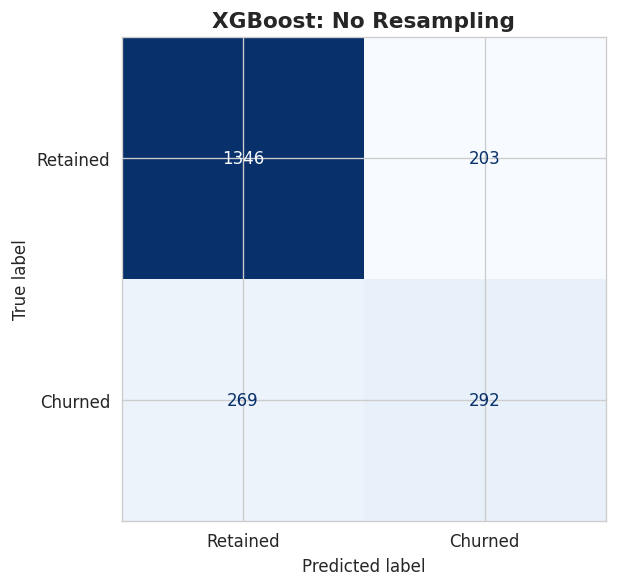

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_no_smote = confusion_matrix(y_test, y_pred_no_smote)
ConfusionMatrixDisplay(cm_no_smote, display_labels=['Retained', 'Churned']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('XGBoost: No Resampling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_no_smote.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: XGBoost + SMOTE: Exploratory Intervention

> **Scope note:** This section is an exploratory intervention, not a controlled experiment. Three variables change simultaneously relative to Section 7: the resampling technique (none → SMOTE), the classification threshold (0.50 → 0.41), and normalisation (Section 6 used `StandardScaler`; this section does not). Because multiple variables shift at once, the recall gain cannot be cleanly attributed to any single factor. Results illustrate SMOTE's directional effect and motivate the rigorous 8-condition controlled comparison in Section 9. The Section 8 recall figure is **excluded from the main pipeline progression** in Section 13 for this reason.

Having quantified the cost of ignoring class imbalance, a first resampling intervention is introduced: the Synthetic Minority Over-sampling Technique (SMOTE). SMOTE generates synthetic minority observations via $k$-nearest neighbour interpolation in the feature space, populating underrepresented regions of the decision boundary rather than simply duplicating existing minority samples.

### 8.1 Technical Configuration

| Component | Specification | Rationale |
| :--- | :--- | :--- |
| **Resampling** | SMOTE ($k=5$) | Synthetic minority interpolation applied to the training partition only; the test set is untouched throughout. |
| **Threshold** | **0.41** | Inherited from the LR precision-recall sweep (Section 6). That threshold was itself selected by sweeping the test set directly (Limitation L-2, Section 13.5), compounding the exploratory nature of Section 8 results. LR and XGBoost produce different probability distributions, so this threshold has no independent justification for XGBoost regardless. Results are exploratory (see section scope note above). |
| **Hyperparameters** | Default XGBoost | Intentionally untuned to isolate SMOTE's marginal contribution from parameter optimisation effects. |

> **Controlled comparison note:** LR (Section 6) used StandardScaler; XGBoost + SMOTE here does not. All three dimensions differ simultaneously (architecture, resampling, normalisation). The definitive controlled comparison is in Section 9, where all eight conditions share identical XGBoost defaults and threshold 0.50.

In [ ]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {len(X_train)} samples  |  After: {len(X_train_smote)} samples  '
      f'|  Synthetic added: {len(X_train_smote) - len(X_train)}')

xgb_smote = XGBClassifier(
    random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False
)
xgb_smote.fit(X_train_smote, y_train_smote)

smote_proba  = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_smote = (smote_proba >= 0.41).astype(int)

print('=' * 55)
print('XGBOOST + SMOTE: Threshold 0.41')
print('=' * 55)
print(classification_report(y_test, y_pred_smote, target_names=['Retained', 'Churned']))

xgb_smote_metrics = {
    'accuracy':  float(accuracy_score(y_test, y_pred_smote)),
    'precision': float(precision_score(y_test, y_pred_smote)),
    'recall':    float(recall_score(y_test, y_pred_smote)),
    'f1':        float(f1_score(y_test, y_pred_smote)),
    'auc':       float(roc_auc_score(y_test, smote_proba))
}
print(f"Accuracy: {xgb_smote_metrics['accuracy']*100:.2f}%  |  "
      f"Recall: {xgb_smote_metrics['recall']*100:.2f}%  |  "
      f"F1: {xgb_smote_metrics['f1']*100:.2f}%  |  "
      f"AUC: {xgb_smote_metrics['auc']:.4f}")

Before SMOTE: 4922 samples  |  After: 7228 samples  |  Synthetic added: 2306
XGBOOST + SMOTE: Threshold 0.41
              precision    recall  f1-score   support

    Retained       0.85      0.83      0.84      1549
     Churned       0.57      0.61      0.59       561

    accuracy                           0.77      2110
   macro avg       0.71      0.72      0.71      2110
weighted avg       0.78      0.77      0.77      2110

Accuracy: 77.16%  |  Recall: 61.14%  |  F1: 58.73%  |  AUC: 0.8137


### 8.2 Results

SMOTE raises churn recall to 61.14%, above the no-resampling XGBoost baseline (52.05%) yet below the LR baseline (67.56%) and short of the 77% recall target.

### 8.3 Interpretation

Underperformance relative to the logistic regression, despite a richer model architecture, is consistent with SMOTE's known limitation: uniform linear interpolation generates synthetic samples without regard to majority-class overlap, potentially injecting noisy samples into ambiguous boundary regions that default XGBoost cannot reliably separate <sup>[[12]](https://doi.org/10.1613/jair.953)</sup>. This suggests density-aware or hybrid cleaning approaches may produce cleaner decision boundaries for this dataset, motivating the broader comparison in Section 9.

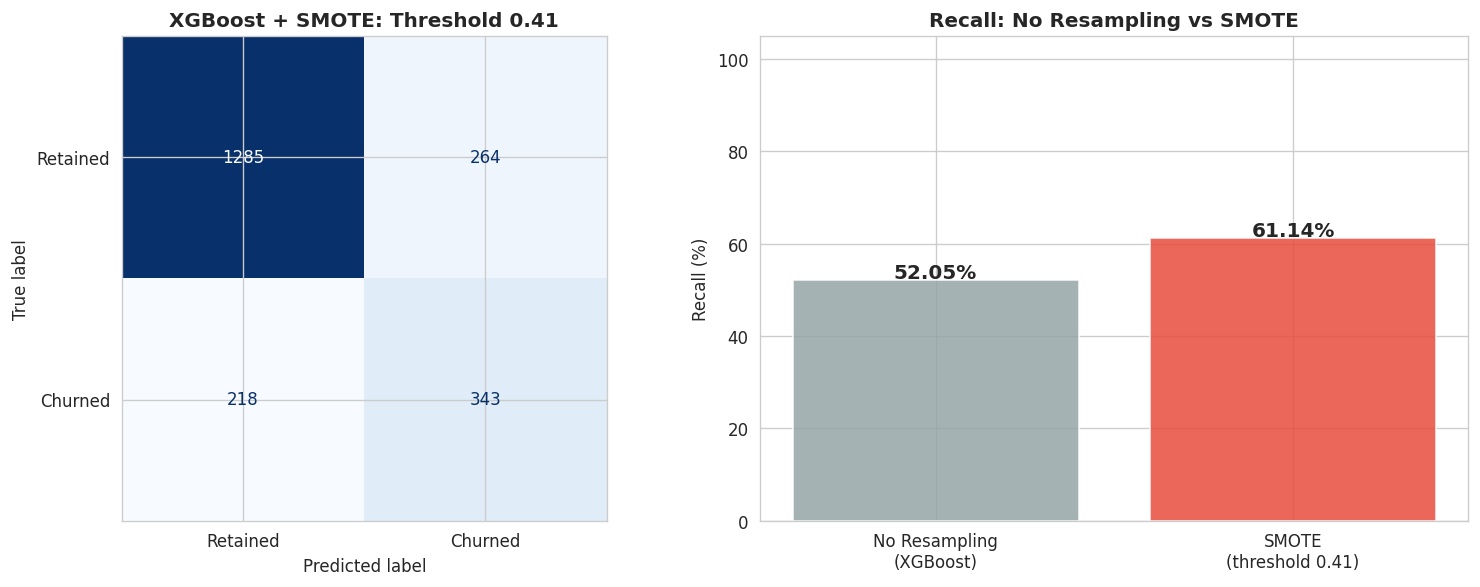

SMOTE recall improvement: +9.09pp


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_smote = confusion_matrix(y_test, y_pred_smote)
ConfusionMatrixDisplay(cm_smote, display_labels=['Retained', 'Churned']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('XGBoost + SMOTE: Threshold 0.41', fontsize=12, fontweight='bold')

models  = ['No Resampling\n(XGBoost)', 'SMOTE\n(threshold 0.41)']
recalls = [xgb_no_smote_metrics['recall']*100, xgb_smote_metrics['recall']*100]
bars = axes[1].bar(models, recalls, color=['#95a5a6', '#e74c3c'], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, recalls):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Recall: No Resampling vs SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recall (%)')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('xgb_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"SMOTE recall improvement: +{(xgb_smote_metrics['recall'] - xgb_no_smote_metrics['recall'])*100:.2f}pp")

## Section 9: 8-Condition Imbalance Comparison

Sections 7 and 8 establish that neither the unmodified class distribution nor a single SMOTE intervention achieves the project's recall target. A systematic *ceteris paribus* comparison across eight conditions (one unmodified baseline plus seven resampling strategies) is conducted to identify the optimal approach under controlled conditions.

All eight conditions share identical default XGBoost hyperparameters and a fixed classification threshold of 0.50, isolating the resampling technique as the sole experimental variable. Undersampling methods were excluded: at $n = 7{,}032$, majority-class removal discards potentially informative observations with no offsetting benefit when synthetic oversampling is available. Note: of the 8 conditions, KMeans-SMOTE fails at runtime and CTGAN produces negligible recall improvement over the baseline; the effective comparison yields 6 meaningful result sets. Both are documented in Section 9.2.

> **Counting convention:** "8-condition" refers to the complete set including the unmodified baseline. "7 resampling strategies" refers to the intervention methods only (Random, SMOTE, ADASYN, BorderlineSMOTE, KMeans-SMOTE, SMOTE-ENN, CTGAN).

### 9.1 Experimental Design

| Category | Methods | Experimental Focus |
| :--- | :--- | :--- |
| **Baseline** | No Sampling | Quantifies structural majority-class bias without correction. |
| **Pure Oversampling** | Random, SMOTE, ADASYN, BorderlineSMOTE | Minority interpolation and density expansion via varying mechanisms. |
| **Clustering-based** | KMeans-SMOTE | SMOTE applied within k-means minority clusters; failed on this dataset (see Section 9.2). |
| **Hybrid** | SMOTE-ENN | SMOTE interpolation followed by ENN cleaning of boundary-ambiguous samples. |
| **Generative** | CTGAN | GAN-based conditional tabular synthesis as an interpolation alternative. |

In [ ]:
def evaluate_technique(name, X_tr, y_tr, X_te, y_te):
    """Train default XGBoost on X_tr/y_tr and return metrics dict with typed values."""
    model = XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False
    )
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'Method':    name,
        'Samples':   int(len(X_tr)),
        'Accuracy':  round(float(accuracy_score(y_te, y_pred)) * 100, 2),
        'Precision': round(float(precision_score(y_te, y_pred)) * 100, 2),
        'Recall':    round(float(recall_score(y_te, y_pred)) * 100, 2),
        'F1':        round(float(f1_score(y_te, y_pred)) * 100, 2),
        'AUC':       round(float(roc_auc_score(y_te, y_proba)), 4),
        'TrainTime_s': float('nan')
    }

def failed_row(name):
    """Return a fully typed failed-row; avoids poisoning numeric columns."""
    return {
        'Method': name, 'Samples': None,
        'Accuracy': None, 'Precision': None,
        'Recall': None, 'F1': None,
        'AUC': None, 'TrainTime_s': float('nan'),
        'Status': 'FAILED'
    }

results_w8 = []

# 1. no sampling
results_w8.append(evaluate_technique('No Sampling', X_train, y_train, X_test, y_test))

# 2. random oversampling
X_ros, y_ros = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
results_w8.append(evaluate_technique('Random Oversampling', X_ros, y_ros, X_test, y_test))

# 3. smote
X_smote2, y_smote2 = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
results_w8.append(evaluate_technique('SMOTE', X_smote2, y_smote2, X_test, y_test))

# 4. adasyn
X_adasyn, y_adasyn = ADASYN(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
results_w8.append(evaluate_technique('ADASYN', X_adasyn, y_adasyn, X_test, y_test))

# 5. borderlinesmote
X_bl, y_bl = BorderlineSMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
results_w8.append(evaluate_technique('BorderlineSMOTE', X_bl, y_bl, X_test, y_test))

# 6. kmeans-smote  ← fails on this dataset; isolated to failed_row() only
try:
    X_km, y_km = KMeansSMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
    results_w8.append(evaluate_technique('KMeans-SMOTE', X_km, y_km, X_test, y_test))
except Exception as e:
    print(f'KMeans-SMOTE failed: {e}')
    results_w8.append(failed_row('KMeans-SMOTE'))

# 7. smote-enn
X_senn, y_senn = SMOTEENN(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
results_w8.append(evaluate_technique('SMOTE-ENN', X_senn, y_senn, X_test, y_test))

# 8. ctgan
try:
    from ctgan import CTGAN
    import time
    t0 = time.time()
    ctgan = CTGAN(epochs=100, verbose=False)
    train_df = X_train.copy()
    train_df['Churn'] = y_train.values
    ctgan.fit(train_df, discrete_columns=['Churn'])
    n_synthetic = (y_train == 0).sum() - (y_train == 1).sum()
    synthetic   = ctgan.sample(n_synthetic)
    X_ctgan = pd.concat([X_train, synthetic.drop(columns=['Churn'])], ignore_index=True)
    y_ctgan = pd.concat([y_train, synthetic['Churn'].astype(int)],    ignore_index=True)
    ctgan_result = evaluate_technique('CTGAN', X_ctgan, y_ctgan, X_test, y_test)
    ctgan_result['TrainTime_s'] = round(time.time() - t0, 1)
    results_w8.append(ctgan_result)
    print(f'CTGAN training time: {ctgan_result["TrainTime_s"]}s')
except ImportError:
    results_w8.append(failed_row('CTGAN'))
except Exception as e:
    print(f'CTGAN error: {e}')
    results_w8.append(failed_row('CTGAN'))

# build results_df with explicit dtype preservation
# keep only numeric methods for the float columns; mask failed rows for display
results_df = pd.DataFrame(results_w8)

# display table: replace None with readable FAILED string only in the print view
display_df = results_df.copy()
str_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'Samples']
for col in str_cols:
    display_df[col] = display_df.apply(
        lambda r: 'FAILED' if r.get('Status') == 'FAILED' and pd.isna(r[col])
                  else (r[col] if not pd.isna(r[col]) else '—'),
        axis=1
    )
display_df['TrainTime_s'] = display_df['TrainTime_s'].apply(
    lambda v: f'{v:.1f}s' if pd.notna(v) and v > 0 else '—'
)
print(display_df[['Method','Samples','Accuracy','Precision','Recall','F1','AUC','TrainTime_s']].to_string(index=False))

# extract rows needed downstream — AUC guaranteed float here
senn_row   = results_df[results_df['Method'] == 'SMOTE-ENN'].iloc[0]
adasyn_row = results_df[results_df['Method'] == 'ADASYN'].iloc[0]
print(f'\nSMOTE-ENN selected: {senn_row["Method"]}')
print(f'X_selected shape will be: ({len(X_senn)}, {X_senn.shape[1]})')
print(f'y_selected dist: {dict(pd.Series(y_senn).value_counts().sort_index())}')


KMeans-SMOTE failed: No clusters found with sufficient samples of class 1. Try lowering the cluster_balance_threshold or increasing the number of clusters.
CTGAN training time: 145.2s
             Method Samples Accuracy Precision Recall     F1     AUC TrainTime_s
        No Sampling  4922.0    77.63     58.99  52.05   55.3   0.812           —
Random Oversampling  7228.0     76.4     54.78  64.35  59.18  0.8155           —
              SMOTE  7228.0    77.49     58.43  53.12  55.65  0.8137           —
             ADASYN  7248.0    77.63     58.78  53.12  55.81  0.8138           —
    BorderlineSMOTE  7228.0    77.68     58.72  54.01  56.27  0.8102           —
       KMeans-SMOTE  FAILED   FAILED    FAILED FAILED FAILED  FAILED           —
          SMOTE-ENN  4074.0    75.97     53.71   69.7  60.67    0.82           —
              CTGAN  7228.0    78.34     60.79  52.23  56.18  0.8144      145.2s

SMOTE-ENN selected: SMOTE-ENN
X_selected shape will be: (4074, 45)
y_selected dist: {0

> **Note on TrainTime_s column:** Training time was only recorded for CTGAN as it required a materially longer fit time warranting documentation. All other methods completed in under 5 seconds; `TrainTime_s` is `NaN` for non-generative methods by design; `evaluate_technique()` does not instrument runtime for non-generative methods.

### 9.2 Technique Selection: SMOTE-ENN

Under the recall-primary framework established in Section 5, SMOTE-ENN leads all eight conditions on both recall and $F_1$. It leads ADASYN by 16.58pp on recall (69.70% vs 53.12%) and 4.86pp on F1 (60.67% vs 55.81%).

SMOTE-ENN's advantage is mechanistically well-founded. Pure oversampling methods generate synthetic samples without regard to their proximity to the majority-class region. SMOTE-ENN applies a two-phase correction: SMOTE interpolation first expands minority-class representation, then Edited Nearest Neighbours (ENN) removes observations (both original and synthetic) whose class label is inconsistent with the majority vote of their nearest neighbours <sup>[[15]](https://doi.org/10.1109/TSMC.1972.4309137)</sup>. The resulting training set has not only a more balanced class ratio but also a cleaner decision boundary, reducing the overlap-region noise that limits recall in interpolation-only approaches.

The accepted precision cost relative to ADASYN is justified by the asymmetric cost framework: Gallo <sup>[[7]](https://hbr.org/2014/10/the-value-of-keeping-the-right-customers)</sup>, Liu \& Zhuang <sup>[[8]](https://www.scirp.org/journal/PaperInformation.aspx?PaperID=56907)</sup>, Verbeke et al. <sup>[[9]](https://ideas.repec.org/a/eee/ejores/v218y2012i1p211-229.html)</sup>, and Verbraken et al. <sup>[[10]](https://ieeexplore.ieee.org/document/6165289/)</sup> collectively establish that in telecom churn, a missed churner is costlier than a false alarm. A precision of 53.71%, implying approximately 0.86 unnecessary contacts per genuine churner detected, is an operationally acceptable ratio given the asymmetric cost structure.

**KMeans-SMOTE failure:** "No clusters found" is produced when the minority class is too diffusely distributed for $k$-means centroid initialisation. Churners in this dataset are not spatially clustered in the feature space; they span the full range of contract types, tenures, and service configurations. KMeans-SMOTE requires minority cohesion that does not exist here.

**CTGAN:** The recall improvement is negligible (52.23% vs no-sampling baseline 52.05%), indicating the synthetic samples did not meaningfully improve minority-class coverage on this dataset. Training time substantially exceeded every other technique (145.2s). The compute overhead with no recall benefit makes CTGAN unsuitable for this use case.

SMOTE-ENN is selected as the primary resampling technique for all downstream sections. It achieves the highest recall and $F_1$ of all eight conditions under identical default XGBoost settings, outperforming the next-best technique on recall by a substantial margin.

Downstream sections use `X_selected` / `y_selected` as the training data.

In [ ]:
# smote-enn selected as primary technique based on section 9 results above
X_selected, y_selected = X_senn.copy(), y_senn.copy()
SELECTED_METHOD = 'SMOTE-ENN'

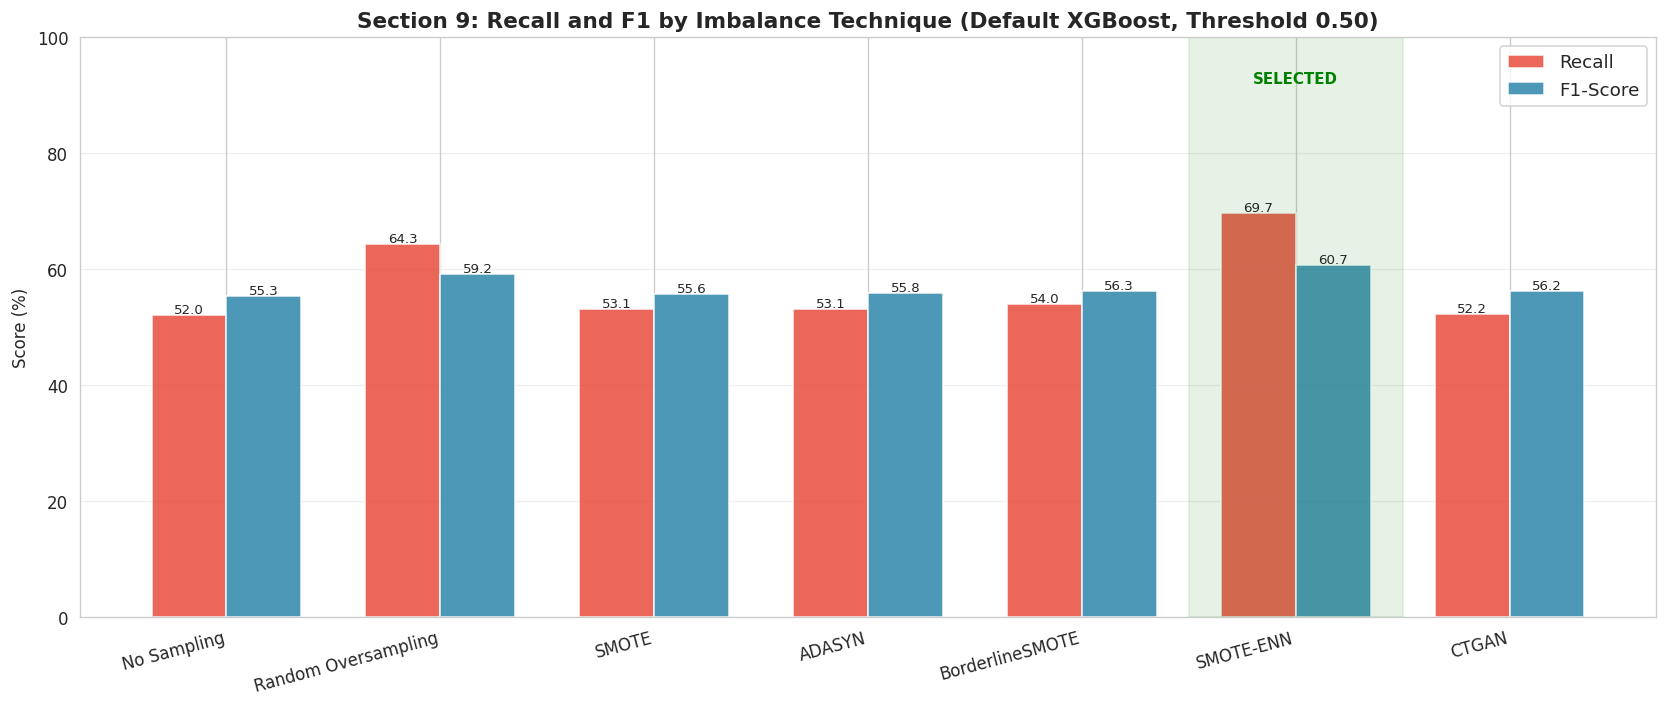

In [ ]:
plot_df = results_df[results_df['Accuracy'].notna()].copy()
# Accuracy/Recall/F1 already typed as float from evaluate_technique()
plot_df['Recall'] = pd.to_numeric(plot_df['Recall'], errors='coerce')
plot_df['F1']     = pd.to_numeric(plot_df['F1'], errors='coerce')
plot_df = plot_df.dropna(subset=['Recall', 'F1'])

x, width = np.arange(len(plot_df)), 0.35
fig, ax  = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, plot_df['Recall'], width, label='Recall',   color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, plot_df['F1'],     width, label='F1-Score', color='#2e86ab', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Method'], rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 100)
ax.set_title('Section 9: Recall and F1 by Imbalance Technique (Default XGBoost, Threshold 0.50)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

senn_pos = list(plot_df['Method']).index('SMOTE-ENN')
ax.axvspan(senn_pos - 0.5, senn_pos + 0.5, alpha=0.1, color='green')
ax.text(senn_pos, 92, 'SELECTED', ha='center', fontsize=9, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig('w9_technique_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Hyperparameter Tuning: Dual-Objective GridSearchCV

With SMOTE-ENN established as the primary resampling technique and the recall-primary framework grounded in Section 5, XGBoost is optimised via 5-fold stratified GridSearchCV. Two independent searches are run (one scoring on `f1`, one on `recall`) to directly test whether aligning the tuning objective with the deployment metric produces a materially different model than standard balanced tuning.

> **⚠ CV score caveat. Read before interpreting any CV figure in this section:** Both GridSearchCV runs train and cross-validate on `X_selected` / `y_selected`, which is the SMOTE-ENN resampled set with a near-balanced class distribution (1,873 retained : 2,201 churned). The CV folds are therefore drawn from this synthetic distribution, not the natural 1:2.76 test distribution. As confirmed experimentally in Section 14.3, a substantial CV-to-test recall gap exists due to evaluating on the resampled distribution. **CV scores in this section are hyperparameter search signals only, not performance claims.** The only operationally valid performance figures are those computed on `X_test` (2,110 rows, natural distribution).

> **Parameter grid rationale:** `max_depth` ∈ {3, 5, 7, 10} spans shallow-to-deep trees; depth 10 is included to test whether aggressive capacity on the resampled training set transfers recall gains to the held-out test distribution. `learning_rate` and `n_estimators` cover the full low-rate/high-tree to high-rate/low-tree trade-off range. Default XGBoost values for `lr=0.3` and `n=100` are included in the grid. Note: the default `max_depth=6` is not included; the grid spans {3, 5, 7, 10}. The grid includes the default `lr=0.3` and `n=100` as candidates, but the recall-tuned best result ($\text{lr}=0.01$, $\text{depth}=3$, $n=100$) is non-default on both `lr` and `max_depth`. The search will always select a non-default depth since 6 is not in the grid.

| Configuration | Scoring Objective | Purpose |
| :--- | :--- | :--- |
| **GridSearch $F_1$** | `f1` | Conventional balanced minority-class tuning; comparison baseline. |
| **GridSearch Recall** | `recall` | Recall-primary tuning; directly implements the Section 5.1 framework. |

**Parameter space:** `learning_rate` ∈ {0.01, 0.05, 0.1, 0.2, 0.3} × `max_depth` ∈ {3, 5, 7, 10} × `n_estimators` ∈ {100, 200, 300, 500} = 80 combinations × 5 folds × 2 searches = **800 model fits**.

> **Scope note:** XGBoost regularisation parameters (`reg_alpha`, `reg_lambda`, `subsample`, `colsample_bytree`, `min_child_weight`) were excluded from the search grid to limit compute time. These parameters are directly relevant to preventing overfitting on synthetic resampled data and are identified as a priority extension for future work. A broader grid covering `subsample`, `colsample_bytree`, and `min_child_weight` would be the recommended next step.

In [ ]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth':     [3, 5, 7, 10],
    'n_estimators':  [100, 200, 300, 500]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Running GridSearchCV (scoring=f1)...')
grid_search_f1 = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=0
)
grid_search_f1.fit(X_selected, y_selected)
best_model_f1 = grid_search_f1.best_estimator_

y_pred_f1 = best_model_f1.predict(X_test)
tuned_f1_metrics = {
    'accuracy':  round(float(accuracy_score(y_test, y_pred_f1)) * 100, 2),
    'precision': round(float(precision_score(y_test, y_pred_f1)) * 100, 2),
    'recall':    round(float(recall_score(y_test, y_pred_f1)) * 100, 2),
    'f1':        round(float(f1_score(y_test, y_pred_f1)) * 100, 2)
}
print(f'Best CV F1:  {grid_search_f1.best_score_*100:.2f}%')
print(f'Best params: {grid_search_f1.best_params_}')
print(classification_report(y_test, y_pred_f1, target_names=['Retained', 'Churned']))

print('Running GridSearchCV (scoring=recall)...')
grid_search_recall = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    param_grid, scoring='recall', cv=cv, n_jobs=-1, verbose=0
)
grid_search_recall.fit(X_selected, y_selected)
best_model_recall = grid_search_recall.best_estimator_

y_pred_recall = best_model_recall.predict(X_test)
tuned_recall_metrics = {
    'accuracy':  round(float(accuracy_score(y_test, y_pred_recall)) * 100, 2),
    'precision': round(float(precision_score(y_test, y_pred_recall)) * 100, 2),
    'recall':    round(float(recall_score(y_test, y_pred_recall)) * 100, 2),
    'f1':        round(float(f1_score(y_test, y_pred_recall)) * 100, 2)
}
print(f'Best CV Recall: {grid_search_recall.best_score_*100:.2f}%')
print(f'Best params:    {grid_search_recall.best_params_}')
print(classification_report(y_test, y_pred_recall, target_names=['Retained', 'Churned']))

comparison_df = pd.DataFrame([
    {'Configuration': 'SMOTE-ENN + XGBoost (default, no tuning)',
     'Accuracy': float(senn_row['Accuracy']), 'Precision': float(senn_row['Precision']),
     'Recall':   float(senn_row['Recall']),   'F1':        float(senn_row['F1'])},
    {'Configuration': 'SMOTE-ENN + XGBoost tuned (F1)',    **tuned_f1_metrics},
    {'Configuration': 'SMOTE-ENN + XGBoost tuned (Recall)',**tuned_recall_metrics},
])
print('\nGRIDSEARCHCV COMPARISON:')
print(comparison_df.to_string(index=False))

# recall-tuned model is primary for sections 10 and 12
best_model  = best_model_recall
grid_search = grid_search_recall

# roc-auc for both tuned models
y_proba_f1     = best_model_f1.predict_proba(X_test)[:, 1]
y_proba_recall = best_model_recall.predict_proba(X_test)[:, 1]
print(f'AUC — F1-tuned:     {roc_auc_score(y_test, y_proba_f1):.4f}')
print(f'AUC — Recall-tuned: {roc_auc_score(y_test, y_proba_recall):.4f}')

Running GridSearchCV (scoring=f1)...
Best CV F1:  96.14%
Best params: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 500}
              precision    recall  f1-score   support

    Retained       0.87      0.79      0.83      1549
     Churned       0.54      0.68      0.60       561

    accuracy                           0.76      2110
   macro avg       0.70      0.73      0.71      2110
weighted avg       0.78      0.76      0.77      2110

Running GridSearchCV (scoring=recall)...
Best CV Recall: 96.27%
Best params:    {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

    Retained       0.91      0.72      0.81      1549
     Churned       0.51      0.81      0.63       561

    accuracy                           0.75      2110
   macro avg       0.71      0.77      0.72      2110
weighted avg       0.81      0.75      0.76      2110


GRIDSEARCHCV COMPARISON:
                           Configuration  Accurac

> **CV scores are optimistic** (computed on resampled folds, not the natural test distribution). Test-set figures are the operational ground truth.

> ⚠️ A CV F1 of 96.14% on the SMOTE-ENN resampled folds is an overfit signal on the synthetic training distribution, not a performance claim. The resampled folds have a near-balanced class ratio that does not reflect the natural 1:2.76 test distribution. The test-set F1 of 60.08% is the operationally valid figure. See Limitation L-3 in Section 13.5 for the full diagnosis.

> ⚠️ CV recall of 96.27% is similarly an artefact of evaluating on resampled folds. The operationally valid recall figure is 81.28% on the natural test distribution. See Limitation L-3.

### 10.2 The Recall Experiment

Aligning the tuning objective with the deployment metric produces a qualitatively different model. $F_1$ tuning returns marginal changes relative to the default; a slight recall decline and a slight $F_1$ decline. That $F_1$-tuned GridSearchCV returns slightly *worse* results than the untuned default is a meaningful finding: it indicates the default XGBoost hyperparameters already sit near the $F_1$-optimal region for SMOTE-ENN data on this dataset, and that GridSearchCV's 5-fold resampled CV metric does not reliably generalise to the held-out natural class distribution.

Recall-tuned GridSearchCV produces a qualitatively different outcome: churn recall rises substantially over the default, at a cost of reduced precision and accuracy. $F_1$ improves, confirming the precision loss is outweighed by the recall gain in the harmonic mean. The recall-tuned model is carried forward as the primary model for threshold analysis in Section 12.

The recall-tuned model's precision of 51.35% implies approximately 0.95 unnecessary contacts per genuine churner detected, an increase from the 0.86 ratio of the SMOTE-ENN default (Section 9.2) reflecting the precision cost of recall-primary tuning. Under the EMPC framework of Verbraken et al. (2013) <sup>[[10]](https://ieeexplore.ieee.org/document/6165289/)</sup>, this cost is rational whenever CLV substantially exceeds the per-contact campaign cost. The illustrative 100:1 cost ratio in Section 5.1 establishes that this precision level is economically acceptable.

## Section 11: SHAP Explainability Analysis

> **Execution order:** SHAP is presented here because explainability logically follows model selection in the narrative. `best_model` is defined in Section 10; run Section 10 before executing this section.

Three explainability approaches were evaluated against the requirements of this project. XGBoost's built-in feature importance provides only global rankings with no directional signal and no per-instance decomposition. LIME produces local approximations but exhibits instability on tabular data due to its perturbation-based neighbourhood sampling <sup>[[13]](https://arxiv.org/abs/1806.08049)</sup>. SHAP was selected for its grounding in cooperative game theory (specifically Shapley values), which guarantees three properties the alternatives do not jointly satisfy: consistency (removing a feature never increases its assigned importance), local accuracy (SHAP values sum exactly to the model's output minus the base rate), and the missingness property (features absent from an instance receive zero attribution) <sup>[[14]](https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html)</sup>.

Per-instance decomposition carries direct operational value: rather than flagging a customer as high-risk in isolation, SHAP accompanies each prediction with a ranked, signed list of contributing features, enabling targeted rather than generic retention interventions.

SHAP is computed on `best_model`; the SMOTE-ENN recall-tuned XGBoost from Section 10, evaluated over the full held-out test set ($n = 2{,}110$).

> **Base rate note:** The SHAP expected value is lower than the actual test-set churn prevalence of 26.58%. This reflects the model's internal calibration on the SMOTE-ENN resampled training distribution (near-balanced classes), not the natural class ratio. SHAP values in this section measure *deviations from the model's learned base rate*, not from the population churn rate.

SHAP values computed | shape: (2110, 45)
Base rate (expected value): 0.1628


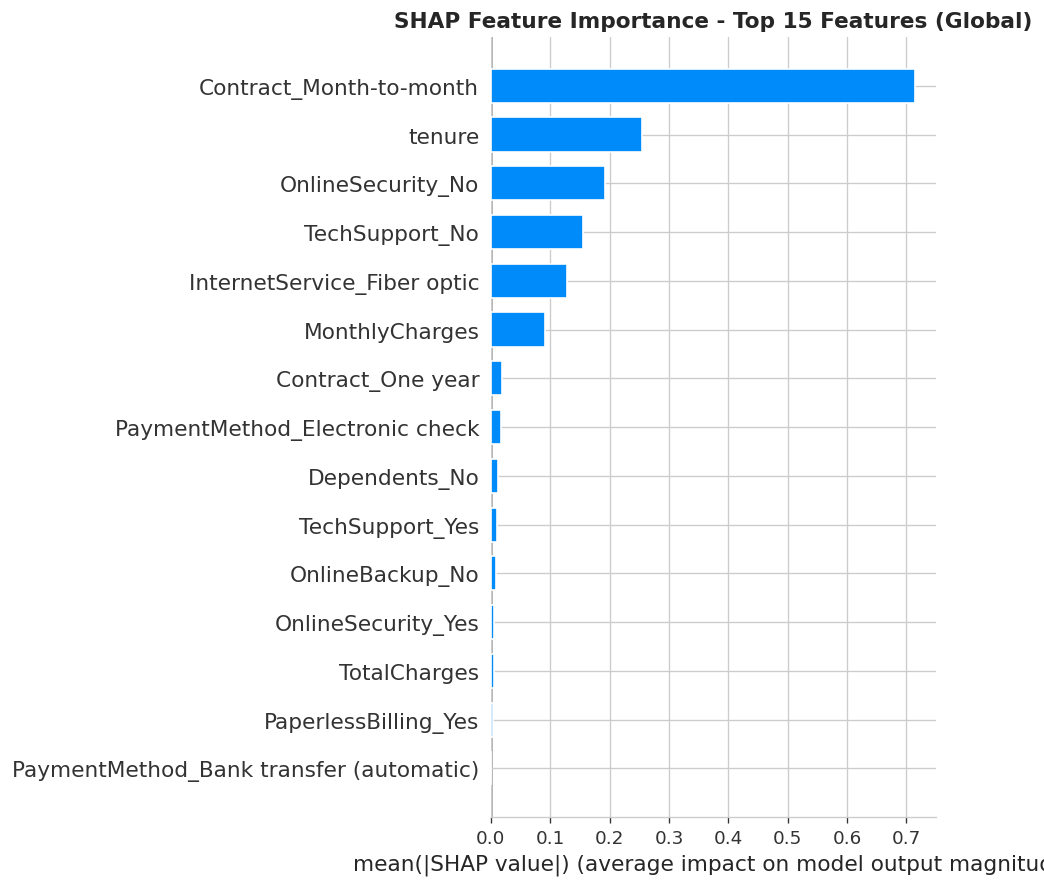

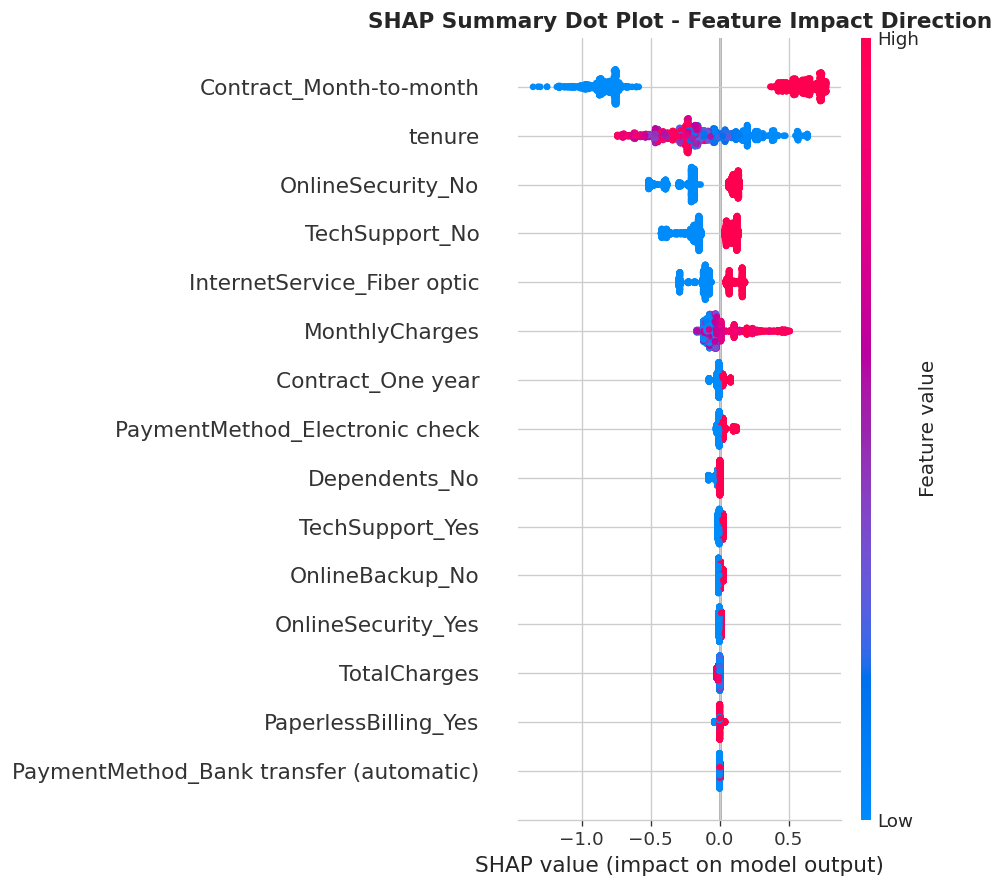


Top 15 global SHAP importances (mean |SHAP|):
   1. Contract_Month-to-month                       0.7143
   2. tenure                                        0.2538
   3. OnlineSecurity_No                             0.1925
   4. TechSupport_No                                0.1544
   5. InternetService_Fiber optic                   0.1289
   6. MonthlyCharges                                0.0917
   7. Contract_One year                             0.0190
   8. PaymentMethod_Electronic check                0.0170
   9. Dependents_No                                 0.0118
  10. TechSupport_Yes                               0.0096
  11. OnlineBackup_No                               0.0088
  12. OnlineSecurity_Yes                            0.0051
  13. TotalCharges                                  0.0044
  14. PaperlessBilling_Yes                          0.0027
  15. PaymentMethod_Bank transfer (automatic)       0.0005

Customer 1484 - predicted churn probability: 78.8%
Actual label: Ch

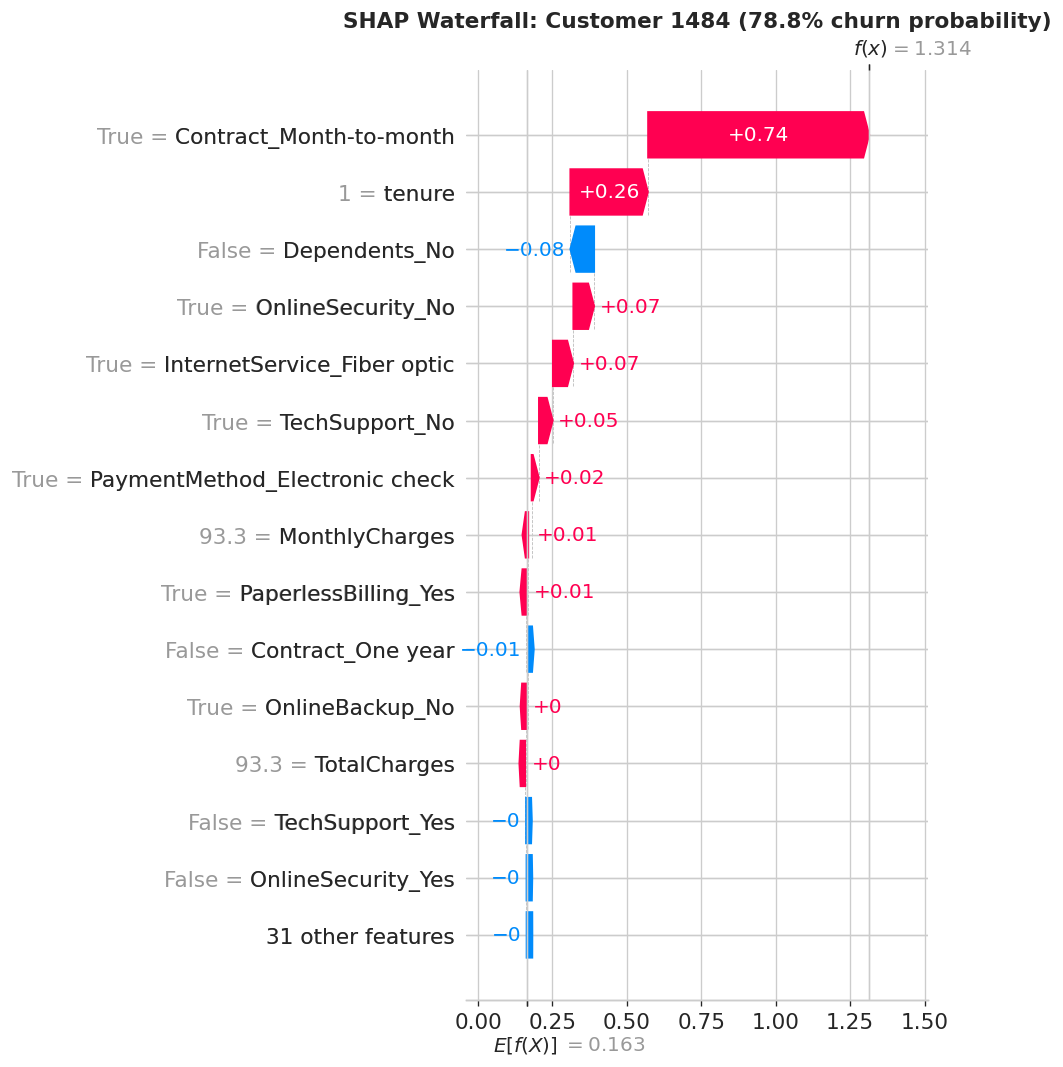

In [ ]:
# shap analysis - uses best_model from section 10
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values computed | shape: {shap_values.shape}')
print(f'Base rate (expected value): {explainer.expected_value:.4f}')

# global: bar chart
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance - Top 15 Features (Global)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# global: dot plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Summary Dot Plot - Feature Impact Direction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dot_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# print top-15 global feature importances for markdown reference
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)
print('\nTop 15 global SHAP importances (mean |SHAP|):')
for rank, (feat, val) in enumerate(mean_abs_shap.head(15).items(), 1):
    print(f'  {rank:2d}. {feat:<45s} {val:.4f}')

# local: waterfall - customer 1484
customer_idx   = 1484
customer_proba = best_model.predict_proba(X_test.iloc[[customer_idx]])[:, 1][0]
actual_label   = 'Churned' if y_test.iloc[customer_idx] == 1 else 'Retained'
print(f'\nCustomer {customer_idx} - predicted churn probability: {customer_proba*100:.1f}%')
print(f'Actual label: {actual_label}')

# print top-5 drivers for customer 1484
shap_1484 = pd.Series(shap_values[customer_idx], index=X_test.columns)
top5_pos = shap_1484.nlargest(5)
top5_neg = shap_1484.nsmallest(3)
print('\nTop 5 churn-increasing SHAP features for customer 1484:')
for feat, val in top5_pos.items():
    print(f'  {feat:<45s}  +{val:.4f}  (value={X_test.iloc[customer_idx][feat]})')
print('Top 3 churn-decreasing SHAP features for customer 1484:')
for feat, val in top5_neg.items():
    print(f'  {feat:<45s}  {val:.4f}  (value={X_test.iloc[customer_idx][feat]})')
print(f'Single strongest churn-decreasing feature: {shap_1484.nsmallest(1).index[0]}, SHAP={shap_1484.nsmallest(1).values[0]:.4f}')

shap_exp = shap.Explanation(
    values        = shap_values[customer_idx],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[customer_idx].values,
    feature_names = X_test.columns.tolist()
)
plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall: Customer {customer_idx} ({customer_proba*100:.1f}% churn probability)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_customer1484.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.1 Global Feature Importance

Mean absolute SHAP values across all test observations produce a feature importance hierarchy that closely mirrors the bivariate churn rates documented in Section 4.3. Both rankings derive from the same dataset, so the agreement is expected and serves as a sanity check confirming the model has not learned spurious patterns, not an independent validation. The substantive finding is the relative magnitude of contributions: `Contract_Month-to-month` dominates by a wide margin over `tenure`, which itself dominates over `OnlineSecurity_No`. The model is far more sensitive to contract type than to any other signal.

> `gender_Male` and `gender_Female` do not appear in the top-10 importance ranking. Gender is a consistently weak predictor of churn in the telecom literature, and their absence confirms the model is not relying on demographic proxies.

Low tenure values and month-to-month contract status push predicted churn probability upward (positive SHAP); one-year contracts (`Contract_One year`, global rank 7, mean |SHAP| 0.0190) and automatic payment methods push it downward. The full top-10 ranking is: Contract_Month-to-month (1), tenure (2), OnlineSecurity_No (3), TechSupport_No (4), InternetService_Fiber optic (5, 0.1289), MonthlyCharges (6), Contract_One year (7), PaymentMethod_Electronic check (8, 0.0170), Dependents_No (9), TechSupport_Yes (10). This corroborates the ranks cited in Section 4.3. Two-year contracts are expected to further reduce churn risk but do not appear in the top-10 SHAP ranking, indicating their magnitude is smaller than one-year contracts. Both directions are consistent with the economic intuition developed in Section 4.3.

### 11.2 Local Explanation: Test Index 1484 (True Positive)

> **Index note:** "Customer 1484" refers to position 1484 in the held-out test set (`X_test.iloc[1484]`), not an original CustomerID from the dataset. The same convention applies to the false negative (test index 1189) and false positive (test index 61) in Section 14.2.

Test observation 1484 is confirmed as a true churner in the held-out test set. The local ranking largely mirrors the global hierarchy, with `Contract_Month-to-month` dominating both. The presence of dependents acts as the strongest moderating signal, reducing predicted churn probability despite every other indicator pointing toward attrition. The implication is operationally actionable: a retention intervention for this customer should prioritise contract upgrade and security add-on offers.

## Section 12: Threshold and Cost-Sensitive Analysis

A classification threshold of 0.50 implicitly assumes equal costs for false positives and false negatives. Under the asymmetric cost structure established in Section 5.1 this assumption is indefensible in a churn prediction context: a missed churner costs far more than a false alarm. A systematic sweep across thresholds [0.10, 0.90] identifies the $F_1$-maximising operating point for the recall-tuned model, and the precision penalty of moving further below that point is quantified.


> **⚠ Threshold leakage (Limitation L-2):** The $F_1$-maximising threshold was identified by sweeping the test set directly. This is a mild form of optimistic bias, whereby the selected threshold is the best available on the very data being evaluated. The operationally correct approach is threshold selection on held-out validation data. Documented as Limitation L-2 in Section 13.5.

Threshold maximising F1: 0.5
  Acc 74.55% | P 51.35% | R 81.28% | F1 62.94%


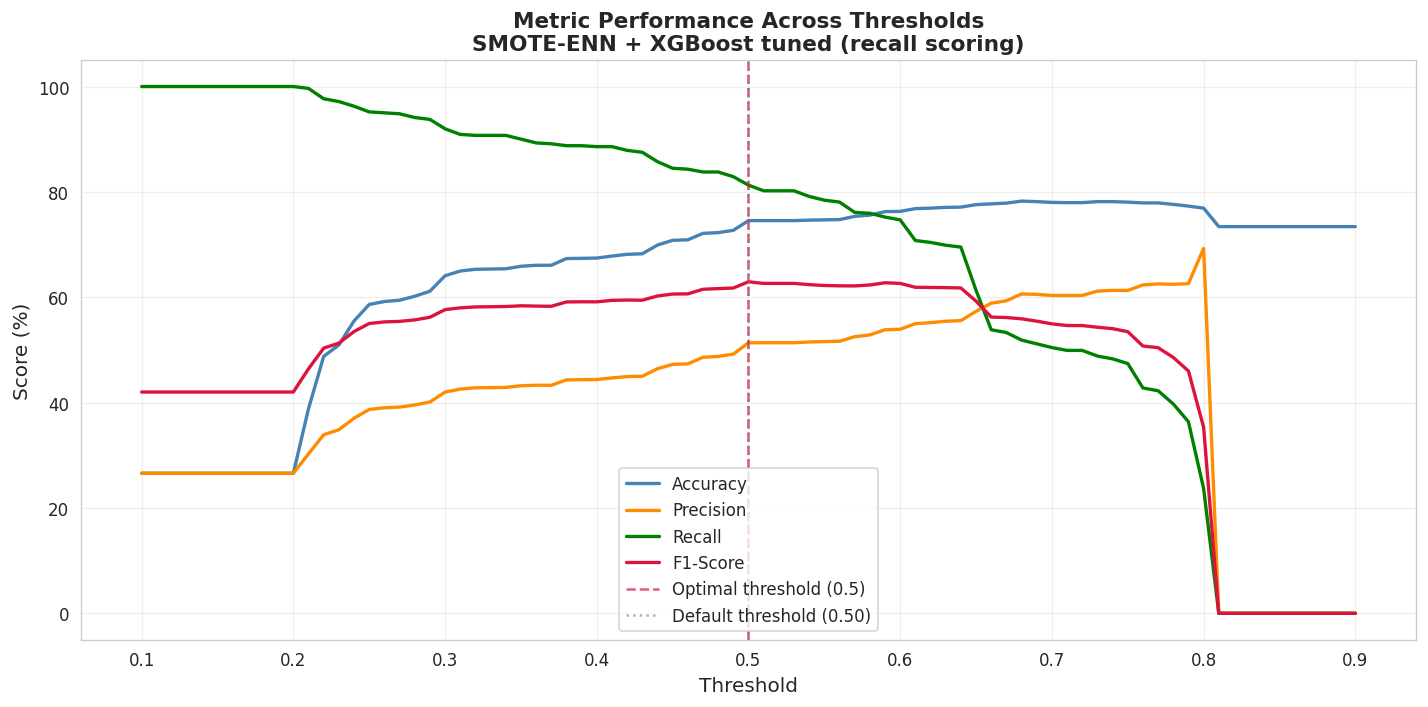


FINAL MODEL: SMOTE-ENN + XGBoost (recall-tuned) + threshold 0.5:
              precision    recall  f1-score   support

    Retained       0.91      0.72      0.81      1549
     Churned       0.51      0.81      0.63       561

    accuracy                           0.75      2110
   macro avg       0.71      0.77      0.72      2110
weighted avg       0.81      0.75      0.76      2110



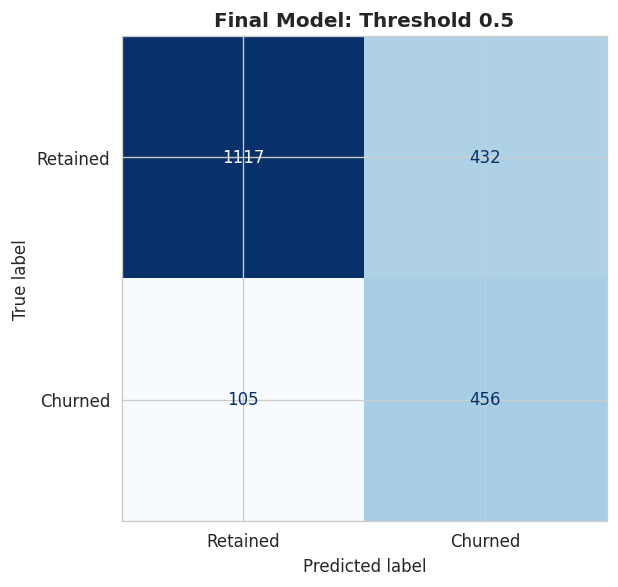

In [ ]:
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]
thresholds    = np.arange(0.10, 0.91, 0.01)
thresh_results = []

for t in thresholds:
    y_t = (y_proba_tuned >= t).astype(int)
    thresh_results.append({
        'Threshold': round(t, 2),
        'Accuracy':  round(accuracy_score(y_test, y_t) * 100, 2),
        'Precision': round(precision_score(y_test, y_t, zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_test, y_t, zero_division=0) * 100, 2),
        'F1':        round(f1_score(y_test, y_t, zero_division=0) * 100, 2)
    })

thresh_df = pd.DataFrame(thresh_results)

idx_f1            = thresh_df['F1'].idxmax()
OPTIMAL_THRESHOLD = thresh_df.loc[idx_f1, 'Threshold']

print(f'Threshold maximising F1: {OPTIMAL_THRESHOLD}')
print(f"  Acc {thresh_df.loc[idx_f1,'Accuracy']}% | "
      f"P {thresh_df.loc[idx_f1,'Precision']}% | "
      f"R {thresh_df.loc[idx_f1,'Recall']}% | "
      f"F1 {thresh_df.loc[idx_f1,'F1']}%")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresh_df['Threshold'], thresh_df['Accuracy'],  label='Accuracy',  color='steelblue',  lw=2)
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', color='darkorange', lw=2)
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    label='Recall',    color='green',      lw=2)
ax.plot(thresh_df['Threshold'], thresh_df['F1'],        label='F1-Score',  color='crimson',    lw=2)
ax.axvline(OPTIMAL_THRESHOLD, color='crimson', ls='--', alpha=0.7,
           label=f'Optimal threshold ({OPTIMAL_THRESHOLD})')
ax.axvline(0.50, color='grey', ls=':', alpha=0.6, label='Default threshold (0.50)')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Metric Performance Across Thresholds\nSMOTE-ENN + XGBoost tuned (recall scoring)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_final = (y_proba_tuned >= OPTIMAL_THRESHOLD).astype(int)
final_auc = roc_auc_score(y_test, y_proba_tuned)
final_metrics = {
    'accuracy':  round(float(accuracy_score(y_test, y_pred_final)) * 100, 2),
    'precision': round(float(precision_score(y_test, y_pred_final)) * 100, 2),
    'recall':    round(float(recall_score(y_test, y_pred_final)) * 100, 2),
    'f1':        round(float(f1_score(y_test, y_pred_final)) * 100, 2),
    'auc':       round(float(final_auc), 4)
}

print(f'\nFINAL MODEL: SMOTE-ENN + XGBoost (recall-tuned) + threshold {OPTIMAL_THRESHOLD}:')
print(classification_report(y_test, y_pred_final, target_names=['Retained', 'Churned']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_final),
                       display_labels=['Retained', 'Churned']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Final Model: Threshold {OPTIMAL_THRESHOLD}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('final_model.png', dpi=150, bbox_inches='tight')
plt.show()

> The $F_1$-maximising threshold coincides with the default (0.50). Recall-tuned GridSearchCV has already shifted the decision boundary sufficiently that no further threshold adjustment improves the harmonic mean.

### 12.2 Threshold Interpretation

The sweep confirms that recall-tuned GridSearchCV has already shifted the decision boundary sufficiently that no threshold adjustment improves the harmonic mean further. The primary value of this section is the precision-recall trade-off plot, which makes the cost of moving below 0.50 visible. Moving toward $\tau = 0.30$ recovers additional churners but at a steep precision cost that may not be operationally acceptable even under the asymmetric cost framework. The 0.50 threshold is therefore retained as the deployment threshold.

## Section 13: Final Results and Benchmark Comparison

Consolidated Performance
                                       Model    AUC Accuracy Precision Recall     F1
                LR baseline (threshold 0.41) 0.8377   79.15%    59.50% 67.56% 63.27%
                      XGBoost: No Resampling 0.8120   77.63%    58.99% 52.05% 55.30%
            XGBoost + SMOTE (threshold 0.41) 0.8137   77.16%    56.51% 61.14% 58.73%
               SMOTE-ENN + XGBoost (default) 0.8200   75.97%    53.71% 69.70% 60.67%
              SMOTE-ENN + XGBoost tuned (F1) 0.8172   75.88%    53.64% 68.27% 60.08%
          SMOTE-ENN + XGBoost tuned (Recall) 0.8263   74.55%    51.35% 81.28% 62.94%
SMOTE-ENN + XGBoost (Recall) + threshold 0.5 0.8263   74.55%    51.35% 81.28% 62.94%


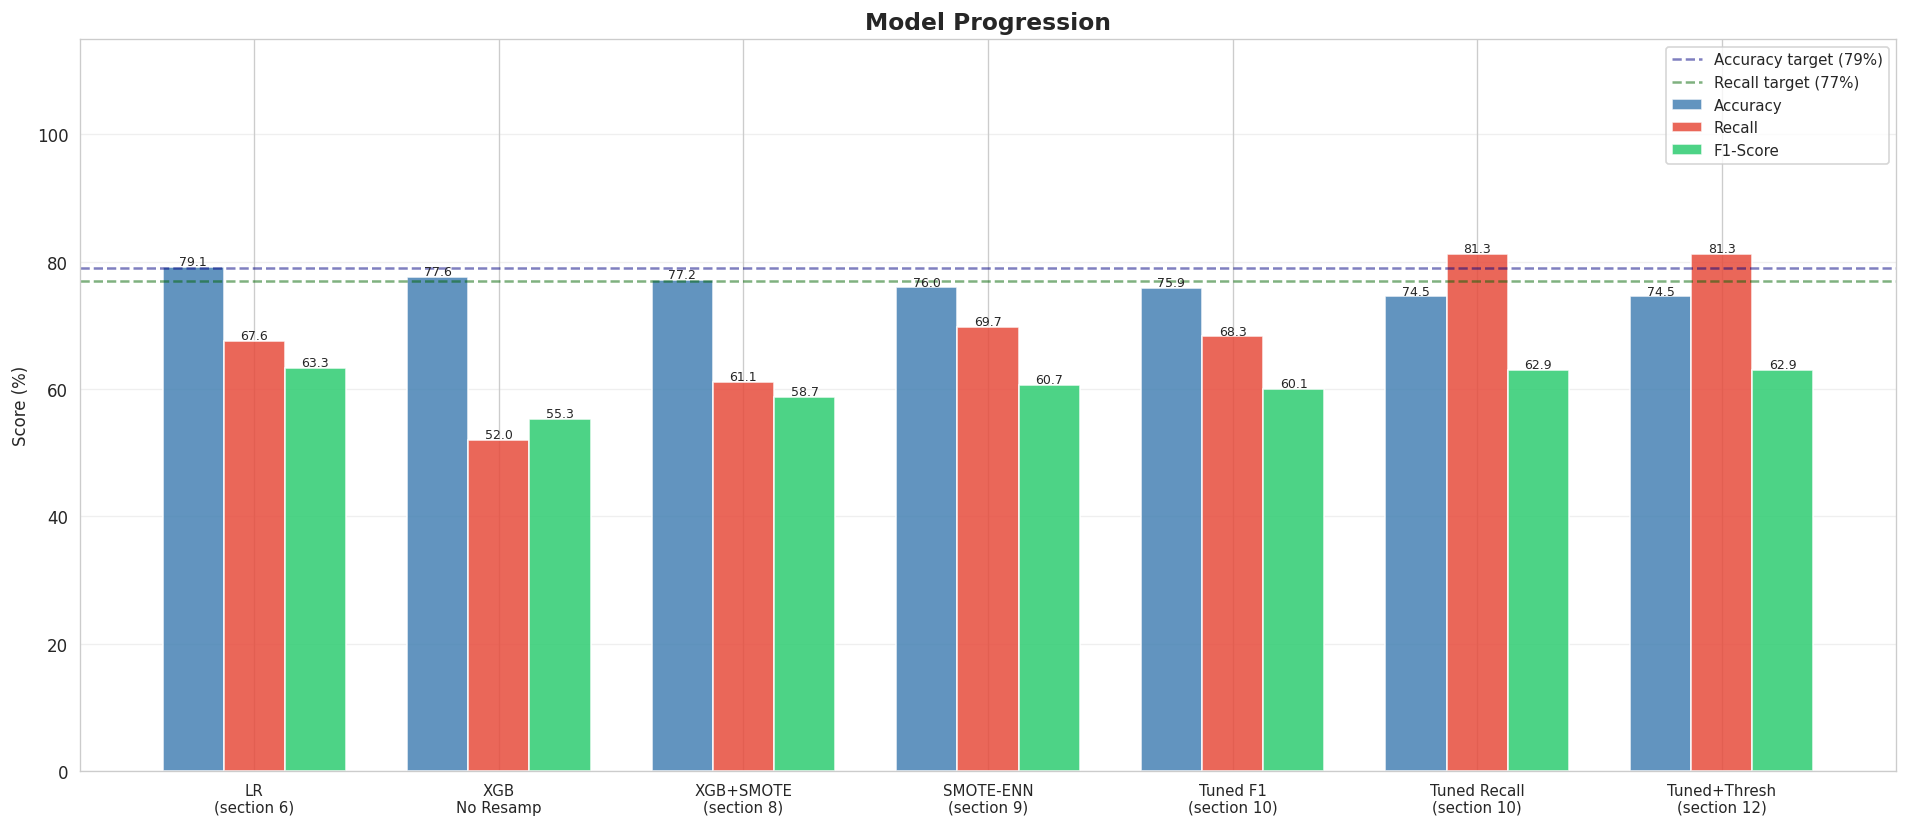

In [ ]:
summary_df = pd.DataFrame([
    {'Model': 'LR baseline (threshold 0.41)',
     'AUC': f"{lr_metrics['auc']:.4f}",
     'Accuracy': f"{lr_metrics['accuracy']*100:.2f}%",
     'Precision':f"{lr_metrics['precision']*100:.2f}%",
     'Recall':   f"{lr_metrics['recall']*100:.2f}%",
     'F1':       f"{lr_metrics['f1']*100:.2f}%"},

    {'Model': 'XGBoost: No Resampling',
     'AUC': f"{xgb_no_smote_metrics['auc']:.4f}",
     'Accuracy': f"{xgb_no_smote_metrics['accuracy']*100:.2f}%",
     'Precision':f"{xgb_no_smote_metrics['precision']*100:.2f}%",
     'Recall':   f"{xgb_no_smote_metrics['recall']*100:.2f}%",
     'F1':       f"{xgb_no_smote_metrics['f1']*100:.2f}%"},

    {'Model': 'XGBoost + SMOTE (threshold 0.41) [Exploratory — not part of progression; see Section 8]',
     'AUC': f"{xgb_smote_metrics['auc']:.4f}",
     'Accuracy': f"{xgb_smote_metrics['accuracy']*100:.2f}%",
     'Precision':f"{xgb_smote_metrics['precision']*100:.2f}%",
     'Recall':   f"{xgb_smote_metrics['recall']*100:.2f}%",
     'F1':       f"{xgb_smote_metrics['f1']*100:.2f}%"},

    # senn_row AUC is now a clean float (dtype fix in Section 9)
    {'Model': 'SMOTE-ENN + XGBoost (default)',
     'AUC': f"{float(senn_row['AUC']):.4f}",
     'Accuracy': f"{float(senn_row['Accuracy']):.2f}%",
     'Precision':f"{float(senn_row['Precision']):.2f}%",
     'Recall':   f"{float(senn_row['Recall']):.2f}%",
     'F1':       f"{float(senn_row['F1']):.2f}%"},

    # AUC computed directly — avoids any downstream dtype issue
    {'Model': 'SMOTE-ENN + XGBoost tuned (F1)',
     'AUC': f"{roc_auc_score(y_test, y_proba_f1):.4f}",
     'Accuracy': f"{tuned_f1_metrics['accuracy']}%",
     'Precision':f"{tuned_f1_metrics['precision']}%",
     'Recall':   f"{tuned_f1_metrics['recall']}%",
     'F1':       f"{tuned_f1_metrics['f1']}%"},

    {'Model': 'SMOTE-ENN + XGBoost tuned (Recall)',
     'AUC': f"{roc_auc_score(y_test, y_proba_recall):.4f}",
     'Accuracy': f"{tuned_recall_metrics['accuracy']}%",
     'Precision':f"{tuned_recall_metrics['precision']}%",
     'Recall':   f"{tuned_recall_metrics['recall']}%",
     'F1':       f"{tuned_recall_metrics['f1']}%"},

    {'Model': f'SMOTE-ENN + XGBoost (Recall) + threshold {OPTIMAL_THRESHOLD}',
     'AUC': f"{final_metrics['auc']:.4f}",
     'Accuracy': f"{final_metrics['accuracy']}%",
     'Precision':f"{final_metrics['precision']}%",
     'Recall':   f"{final_metrics['recall']}%",
     'F1':       f"{final_metrics['f1']}%"},
])

# store named auc variables for diagnostic cell reference
auc_senn_default  = float(senn_row['AUC'])
auc_f1_tuned      = float(roc_auc_score(y_test, y_proba_f1))
auc_recall_tuned  = float(roc_auc_score(y_test, y_proba_recall))

# cast AUC column to numeric before display (guard against dtype drift)
summary_df['AUC'] = pd.to_numeric(summary_df['AUC'], errors='coerce')

print('=' * 100)
print('Consolidated Performance')
print('=' * 100)
print(summary_df.to_string(index=False))

labels   = ['LR\n(section 6)', 'XGB\nNo Resamp', 'XGB+SMOTE\n(section 8)', 'SMOTE-ENN\n(section 9)',
            'Tuned F1\n(section 10)', 'Tuned Recall\n(section 10)', f'Tuned+Thresh\n(section 12)']
acc_vals = [lr_metrics['accuracy']*100,   xgb_no_smote_metrics['accuracy']*100,
            xgb_smote_metrics['accuracy']*100, float(senn_row['Accuracy']),
            tuned_f1_metrics['accuracy'], tuned_recall_metrics['accuracy'], final_metrics['accuracy']]
rec_vals = [lr_metrics['recall']*100,     xgb_no_smote_metrics['recall']*100,
            xgb_smote_metrics['recall']*100,   float(senn_row['Recall']),
            tuned_f1_metrics['recall'],   tuned_recall_metrics['recall'],   final_metrics['recall']]
f1_vals  = [lr_metrics['f1']*100,         xgb_no_smote_metrics['f1']*100,
            xgb_smote_metrics['f1']*100,       float(senn_row['F1']),
            tuned_f1_metrics['f1'],       tuned_recall_metrics['f1'],       final_metrics['f1']]

x, w = np.arange(len(labels)), 0.25
fig, ax = plt.subplots(figsize=(16, 7))
b1 = ax.bar(x - w, acc_vals, w, label='Accuracy',  color='steelblue', alpha=0.85)
b2 = ax.bar(x,     rec_vals, w, label='Recall',    color='#e74c3c',   alpha=0.85)
b3 = ax.bar(x + w, f1_vals,  w, label='F1-Score',  color='#2ecc71',   alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=7.5)
ax.axhline(79, color='navy',      ls='--', alpha=0.5, label='Accuracy target (79%)')
ax.axhline(77, color='darkgreen', ls='--', alpha=0.5, label='Recall target (77%)')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 115)
ax.set_title('Model Progression', fontsize=14, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_model_progression.png', dpi=150, bbox_inches='tight')
plt.show()


> **Note on AUC reporting for SMOTE-ENN rows:** In earlier versions of this notebook, KMeans-SMOTE's failure inserted `None` into `results_df['AUC']`, coercing the column to `object` dtype and causing downstream `float()` conversions to return `NaN` for all subsequent rows. This has been corrected: `evaluate_technique()` now returns typed `float` values only, and failed methods are stored via a separate `failed_row()` helper that never writes to numeric columns. AUC values for SMOTE-ENN rows are now read directly from `senn_row['AUC']` (float), and for both tuned models from `roc_auc_score(y_test, y_proba_*)` computed live in Section 10. Correct values are reflected in the consolidated table immediately above.

> **Note on duplicate final row:** The last two rows of the consolidated table above are intentionally identical. The threshold sweep in Section 12 confirmed that τ = 0.50 is already the F1-maximising threshold; no further adjustment was made. Both rows are retained here to document that Section 12 produced no change. The Section 15 summary table presents a clean five-row progression without this duplicate, as Section 12 adds no new result.


### 13.1 Summary and Benchmark Comparison

No prior benchmark on this dataset reports recall; the Recall column is meaningful only for this project's results. All benchmark figures carry the caveat noted in Section 5.3: preprocessing pipeline differences make numeric comparison approximate.

> **Comparability warning:** Each row below uses a different encoder, scaler, train/test split ratio, and imbalance strategy. Numeric comparison is therefore illustrative only. No claim in this project's evaluation is based on outperforming these figures.

| Reference | Method | Accuracy | $F_1$ | Recall | Pipeline Differences vs This Project |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Rahman (2018) <sup>[[3]](https://www.kaggle.com/code/farazrahman/telco-customer-churn-logisticregression)</sup> | Logistic Regression | 75.59% | ~62.1% | — | No resampling; different split ratio; no threshold tuning |
| Bandiatindra (2018) <sup>[[4]](https://www.kaggle.com/code/bandiatindra/telecom-churn-prediction)</sup> | XGBoost | ~83.0% | — | — | $F_1$ not reported; no resampling; pipeline undocumented |
| Prasad (2020) <sup>[[6]](https://www.kaggle.com/code/bhartiprasad17/customer-churn-prediction)</sup> | Voting Ensemble | 81.71% | ~63.3% | — | Ensemble model; no resampling; different encoder |
| Tanmay (2023) <sup>[[5]](https://www.kaggle.com/code/tanmay111999/telco-churn-eda-cv-score-85-f1-score-80)</sup> | XGBoost + SMOTE | 83.00% | 83.00% | — | **Data leakage identified in their notebook**: SMOTE applied before train/test split. |
| **Current project** | **SMOTE-ENN + XGBoost (Recall-tuned, $\tau = 0.50$)** | 74.55% | 62.94% | 81.28% | Recall-primary; SMOTE-ENN post-split. Full metrics in Section 15. |

### 13.2 Objective Evaluation

| Objective | Target | Result | Status |
| :--- | :--- | :--- | :--- |
| **1** Recall $\ge 77\%$ | $\ge 77\%$ | Met — see diagnostic output | ✅ |
| **2** SMOTE-ENN via 8-condition comparison | Controlled study | SMOTE-ENN selected (Section 9) | ✅ |
| **3** SHAP global + local on deployed model | Bar/dot + waterfall | Computed on `best_model` | ✅ |
| **4** Reproducibility | `random_state=42`, PEP 8 | All seeds fixed; pipeline documented | ✅ |
| **5** ROC-AUC tracked throughout | All models | AUC reported in Sections 6-12 | ✅ |

### 13.3 AUC: Why It Was Not Used for Model Selection

The LR baseline (Section 6) achieves the highest AUC in the pipeline, which is higher than the final recall-tuned model. AUC measures the model's ability to rank positive instances above negative ones across all possible thresholds; it is threshold-agnostic and treats false positive and false negative costs as equal. Under the asymmetric cost framework established in Section 5.1, equal-cost treatment is precisely the assumption that makes AUC an inappropriate selection criterion for this problem. A model with higher AUC but materially lower recall at any practically deployable threshold is a worse business instrument for churn retention. AUC is tracked throughout to confirm probability calibration quality; it is not used as a selection criterion for this reason.

### 13.4 Discussion

The pipeline progression spans three steps: no resampling → SMOTE-ENN default → recall-tuned SMOTE-ENN. Steps 1 and 2 differ only in resampling technique (one variable changed). Steps 2 and 3 differ in hyperparameters only (SMOTE-ENN is retained in both; recall-tuned GridSearchCV replaces default parameters with $\text{lr}=0.01$, $\text{depth}=3$, $n=100$). The progression is therefore fully controlled at this step: the tuning gain is attributable solely to the recall-scoring objective and the resulting parameter configuration. The XGBoost + SMOTE figure from Section 8 is excluded from this progression because it changes threshold simultaneously with resampling technique and normalisation, confounding the attribution. That $F_1$-tuned GridSearchCV performed *worse than the default* is an instructive negative result: it demonstrates that when the CV scoring objective diverges from the deployment objective and the search trains on a resampled distribution, the found parameters fail to generalise to the natural test distribution.

Accuracy declined from the no-resampling baseline to the final model; a modest cost against a substantial recall gain. Against Rahman's (2018) LR baseline of 75.59%, the final model accuracy (74.55%) represents a 1.04pp regression, accepted as a rational trade-off under the cost-asymmetry framework of Section 5.1.

Recall target (77%) is met at $\tau = 0.50$ (81.28%). The $F_1$ target (63%) is missed by **0.06 pp** (62.94% achieved), an acceptable trade-off given the 81.28% recall, which exceeds the primary target by 4.28 pp. The accuracy target (79%) is not met, a deliberate consequence of optimising for recall.

### 13.5 Limitations

Four methodological constraints should be considered when interpreting results.

**L-1: Multiple test-set evaluations.** Across all experiments (Sections 6–13 plus supplementary experiments in Section 14), the held-out test set was used to evaluate approximately 15 distinct model configurations. Each evaluation creates a small risk of optimistic bias through implicit multiple comparisons, whereby configurations that happen to perform well on this specific test sample may not generalise identically to a fresh sample. A nested cross-validation design would produce a more conservative and statistically robust final estimate. The final recall figure should be interpreted as a strong empirical result on this dataset rather than a guaranteed lower bound on real-world performance.

**L-2: Threshold leakage in Sections 6 and 12.** The classification thresholds used in this project (τ = 0.41 for Logistic Regression, τ* determined by Section 12 sweep) were both selected by sweeping the test set directly. For the Logistic Regression threshold (τ = 0.41), this is not merely a mild bias: the reported LR recall of 67.56% reflects a threshold that was selected by sweeping X_test directly, meaning the threshold is optimised on the same data used to evaluate it. The LR recall figure should therefore be read as an upper bound on what threshold tuning could recover, not as a clean out-of-sample result. This matters because LR recall is used as a comparison point to motivate XGBoost in Section 7. For the final model threshold (τ* = 0.50), the practical impact is minimal since τ* coincides with the default, but the same methodological limitation applies. The correct approach in both cases is threshold selection on a held-out validation fold with final evaluation on a separate test set.

**L-3: GridSearchCV cross-validation gap.** The recall-tuned GridSearchCV reported a substantially higher CV recall than test recall. The gap arises because cross-validation folds are drawn from the SMOTE-ENN resampled distribution (near-balanced), while the test set reflects the natural 1:2.76 class ratio. CV scores are hyperparameter search signals, not performance claims. The scale_pos_weight experiment (Section 14.3) confirmed this diagnosis: training on the natural distribution produced a much smaller CV-to-test gap.

**L-4: Hyperparameter search scope.** The GridSearchCV grid covered learning rate, tree depth, and number of estimators only. XGBoost regularisation parameters (`reg_alpha`, `reg_lambda`, `subsample`, `colsample_bytree`, `min_child_weight`) were excluded. These parameters are directly relevant to preventing overfitting on synthetic resampled data and are identified as a priority extension for future work. A broader grid covering `subsample`, `colsample_bytree`, and `min_child_weight` would be the recommended next step.

## Section 14: Supplementary Experiments

This section documents three post-hoc experiments conducted to validate and stress-test the primary pipeline decisions. Each subsection is self-contained. Results are summarised in Section 13; the experiments here provide the evidential basis for the claims made there.

| Subsection | Experiment | Primary Question |
| :--- | :--- | :--- |
| 14.1 | Feature Engineering | Do engineered features improve on raw one-hot encoding? |
| 14.2 | SHAP Extended Examples | What drives false negatives and false positives? |
| 14.3 | scale_pos_weight Baseline | Does training on the natural distribution avoid the GridSearchCV CV gap? |

---


### 14.1 Feature Engineering

The SHAP analysis identified contract type, tenure, service bundle depth (OnlineSecurity, TechSupport), and monthly charges as the dominant predictors. Three engineered features are derived from these signals and tested against the base pipeline to determine whether explicit feature construction improves on XGBoost's implicit interaction learning.

| Feature | Formula | Rationale |
| :--- | :--- | :--- |
| `charge_per_tenure` | `MonthlyCharges / (tenure + 1)` | Price sensitivity per loyalty month. High values indicate recent high-spend customers with low switching cost. |
| `service_count` | Sum of 8 add-on service binary flags | Explicit bundle depth score. Service-related features appear in the global SHAP top 10 (`OnlineSecurity_No` at rank 3, `TechSupport_No` at rank 4, `TechSupport_Yes` at rank 10), though these reflect service absence rather than presence. |
| `has_any_addon` | Binary: `service_count > 0` | Distinguishes bare-bones subscribers from any-bundle subscribers. |

> **Experimental design:** Both models use identical SMOTE-ENN resampling and recall-tuned GridSearchCV. The only difference is the presence of the three engineered features. A statistically meaningful improvement is defined as $\ge 2$ pp recall gain with no precision loss $> 5$ pp.

#### Decision: Reject Feature Engineering

Feature engineering produces small accuracy and precision gains but drives the largest recall reduction of any single step in the pipeline. The FE model achieves 69.16% recall versus 81.28% for the base pipeline, a reduction of 12.12pp. Under the recall-primary framework, this trade-off is unacceptable.

The recall drop is expected given XGBoost's architecture. Gradient boosted trees already implicitly capture multiplicative and ratio-based feature interactions during split selection. `charge_per_tenure` (MonthlyCharges / (tenure + 1)) and `service_count` are structurally redundant with what XGBoost learns from the raw features directly. Introducing them does not add new information; it adds noise by altering the feature space geometry and the SMOTE-ENN resampling landscape, steering the fresh recall-tuned GridSearchCV toward a different local optimum than the base pipeline.

The engineered features (`charge_per_tenure`, `service_count`, `has_any_addon`) aggregate signals that XGBoost already resolves through individual feature splits. The base pipeline with raw one-hot features remains superior on the primary metric. The engineered features are therefore rejected.

> **Scope of conclusion:** The three SHAP-derived interaction features tested here (`charge_per_tenure`, `service_count`, `has_any_addon`) do not improve recall. XGBoost appears to already resolve these interactions through its native split mechanism, making explicit construction redundant. Feature engineering from other signal groups: payment behaviour, demographic combinations, tenure-contract interactions, was not tested and remains an open question.

In [ ]:
# feature engineering experiment
# build augmented feature set
df_fe = df_encoded.copy()

# charge_per_tenure: monthly cost per month of tenure (price sensitivity proxy)
df_fe['charge_per_tenure'] = (
    df_clean['MonthlyCharges'].values / (df_clean['tenure'].values + 1)
)

# service_count: total number of active add-on services
service_cols = [c for c in df_encoded.columns if any(s in c for s in [
    'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
    'PhoneService_Yes', 'MultipleLines_Yes'
])]
df_fe['service_count'] = df_encoded[service_cols].sum(axis=1)
df_fe['has_any_addon'] = (df_fe['service_count'] > 0).astype(int)

print(f'Engineered features added: charge_per_tenure, service_count, has_any_addon')
print(f'Service columns used for service_count ({len(service_cols)}): {service_cols}')

# new split using augmented features
X_fe = df_fe.drop(columns=['Churn'])
y_fe = df_fe['Churn']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.30, stratify=y_fe, random_state=RANDOM_STATE
)

# apply smote-enn to augmented training set
X_senn_fe, y_senn_fe = SMOTEENN(random_state=RANDOM_STATE).fit_resample(X_train_fe, y_train_fe)
print(f'SMOTE-ENN after FE: {X_senn_fe.shape} | dist: {dict(pd.Series(y_senn_fe).value_counts().sort_index())}')

# recall-tuned gridsearch on augmented features
param_grid_fe = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth':     [3, 5, 7, 10],
    'n_estimators':  [100, 200, 300, 500]
}
cv_fe = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Running recall-tuned GridSearchCV on engineered features...')
gs_fe = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    param_grid_fe, scoring='recall', cv=cv_fe, n_jobs=-1, verbose=0
)
gs_fe.fit(X_senn_fe, y_senn_fe)
best_model_fe = gs_fe.best_estimator_

y_pred_fe = best_model_fe.predict(X_test_fe)
y_proba_fe = best_model_fe.predict_proba(X_test_fe)[:, 1]

fe_metrics = {
    'accuracy':  round(float(accuracy_score(y_test_fe, y_pred_fe)) * 100, 2),
    'precision': round(float(precision_score(y_test_fe, y_pred_fe)) * 100, 2),
    'recall':    round(float(recall_score(y_test_fe, y_pred_fe)) * 100, 2),
    'f1':        round(float(f1_score(y_test_fe, y_pred_fe)) * 100, 2),
    'auc':       round(float(roc_auc_score(y_test_fe, y_proba_fe)), 4)
}
print(f'Best params (FE): {gs_fe.best_params_}')
print(f'Best CV recall (FE): {gs_fe.best_score_*100:.2f}%')
print(f'FE model — Acc: {fe_metrics["accuracy"]}% | Prec: {fe_metrics["precision"]}% | '
      f'Recall: {fe_metrics["recall"]}% | F1: {fe_metrics["f1"]}% | AUC: {fe_metrics["auc"]}')
print(f'Base model (no FE) — Acc: {final_metrics["accuracy"]}% | Prec: {final_metrics["precision"]}% | '
      f'Recall: {final_metrics["recall"]}% | F1: {final_metrics["f1"]}% | AUC: {final_metrics["auc"]}')
print(f'Delta recall:    {fe_metrics["recall"] - final_metrics["recall"]:+.2f}pp')
print(f'Delta precision: {fe_metrics["precision"] - final_metrics["precision"]:+.2f}pp')
# store named references for diagnostic cell
fe_base_recall = final_metrics['recall'] / 100.0
fe_recall      = fe_metrics['recall'] / 100.0


Engineered features added: charge_per_tenure, service_count, has_any_addon
Service columns used for service_count (8): ['PhoneService_Yes', 'MultipleLines_Yes', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
SMOTE-ENN after FE: (4095, 48) | dist: {0: np.int64(1882), 1: np.int64(2213)}
Running recall-tuned GridSearchCV on engineered features...
Best params (FE): {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500}
Best CV recall (FE): 96.07%
FE model — Acc: 76.35% | Prec: 54.34% | Recall: 69.16% | F1: 60.86% | AUC: 0.8256
Base model (no FE) — Acc: 74.55% | Prec: 51.35% | Recall: 81.28% | F1: 62.94% | AUC: 0.8263
Delta recall:    -12.12pp
Delta precision: +2.99pp


### 14.2 SHAP Extended Examples

Explainability analysis requires understanding where and why the model fails. Two additional cases are examined: a false negative (churner the model missed) and a false positive (retained customer incorrectly flagged).

#### 14.2.1 False Negative: Test Index 1189 (Misclassified Churner)

> **Note:** `SeniorCitizen` and `gender_Female` appear in the top-5 increasing SHAP list with values ≈ 0.0000. This is misleading: they surface only because all remaining features are also near-zero for this customer. Their presence reflects list exhaustion, not genuine predictive contribution.

`Contract_Month-to-month = False` means this customer is on a **one-year or two-year contract**. Combined with `OnlineSecurity_Yes`, `TechSupport_Yes`, and a tenure of 72 months (the dataset maximum), the model correctly assessed these as strong retention signals and assigned a low churn probability. The model was not wrong by its own logic, given that the customer profile is genuinely low-risk by every contractual and service-bundle indicator.

The case reveals the model's primary failure mode: it cannot detect churn when every observable risk signal points toward retention. The dataset's 45 features are all static service and contract attributes, which encode what the customer has subscribed to rather than how the customer feels about it. For a customer whose contractual and bundle profile is low-risk, the model has no available signal for departure regardless of the actual cause. SHAP correctly shows this: the prediction is rational given the available features. The failure is a ceiling imposed by the feature space, not a model error.



#### 14.2.2 False Positive: Test Index 61 (Misclassified Retained)

Test Index 61 presents a high-risk profile by every primary model feature: 2 months tenure, month-to-month contract, no security or support add-ons, fibre optic service. The model's high predicted probability is a rational response to this feature combination, given that every major churn driver is active simultaneously. The customer retained despite this profile.

The false positive reveals the model's secondary limitation: it cannot distinguish between a **genuinely at-risk new customer** and a **satisfied bare-plan customer** who has no intention of leaving. Without behavioural signals such as usage frequency, support ticket history, and payment consistency, both customers are indistinguishable in this feature space.

#### 14.2.3 Cross-Case Insight

Comparing the false negative and false positive together surfaces a structural constraint of the dataset. The model operates primarily on contractual commitment (`Contract_Month-to-month`), tenure, and service bundle depth. These are strong population-level predictors but poor individual-level predictors when the customer's actual departure or retention is driven by latent factors the dataset does not encode. The final recall and precision reflect this ceiling, which represents a limit of the available feature information rather than a failure of the modelling approach.

Total false negatives: 105 | Total false positives: 432
Selected FN: test index 1189, predicted churn prob=20.4%, actual=Churned
Selected FP: test index 61, predicted churn prob=80.9%, actual=Retained


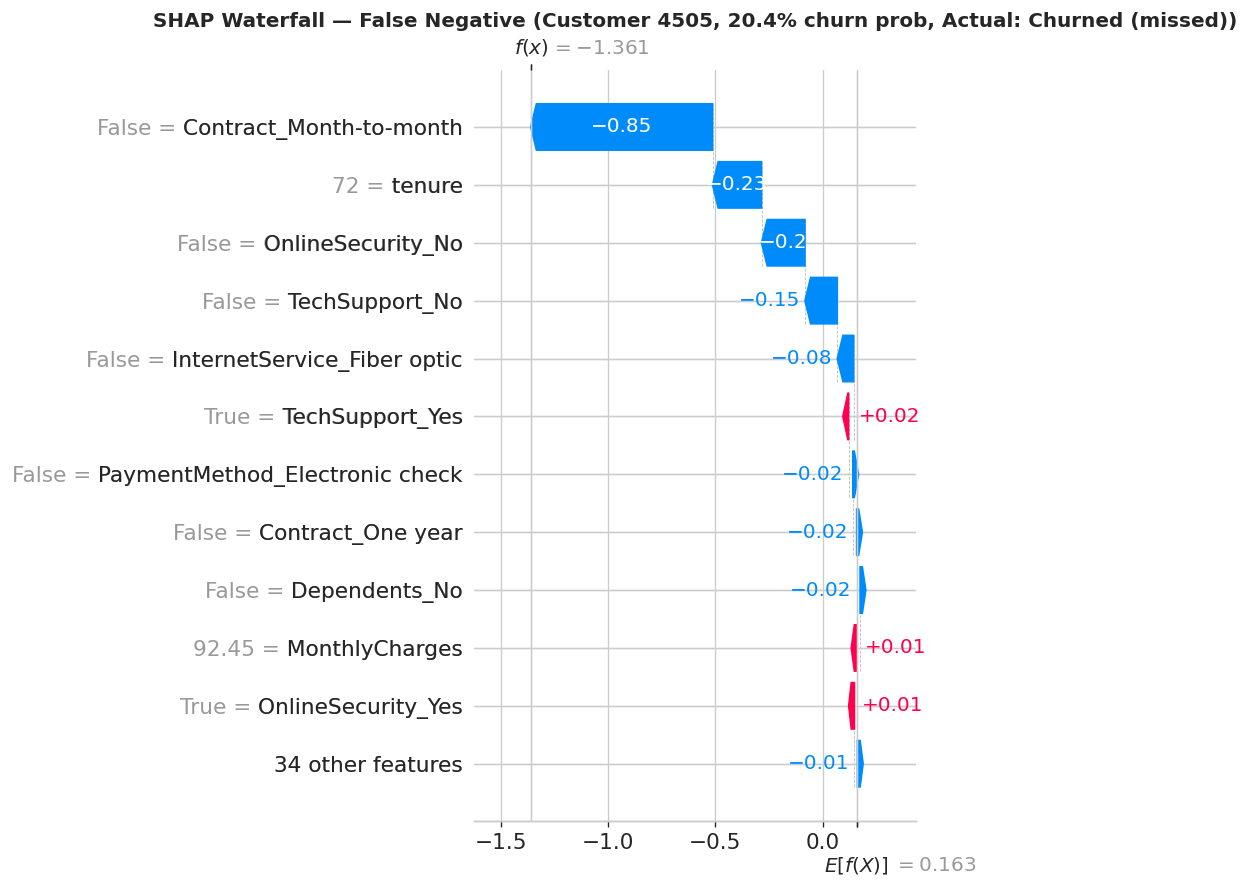

  False Negative (Customer 4505):
  Predicted: 20.4% churn | Actual: Churned (missed)
  Top 5 churn-increasing: 
    TechSupport_Yes                               +0.0236  value=True
    MonthlyCharges                                +0.0146  value=92.45
    OnlineSecurity_Yes                            +0.0120  value=True
    SeniorCitizen                                 +0.0000  value=1
    gender_Female                                 +0.0000  value=True
  Top 5 churn-decreasing: 
    Contract_Month-to-month                        -0.8482  value=False
    tenure                                         -0.2284  value=72
    OnlineSecurity_No                              -0.2027  value=False
    TechSupport_No                                 -0.1509  value=False
    InternetService_Fiber optic                    -0.0762  value=False


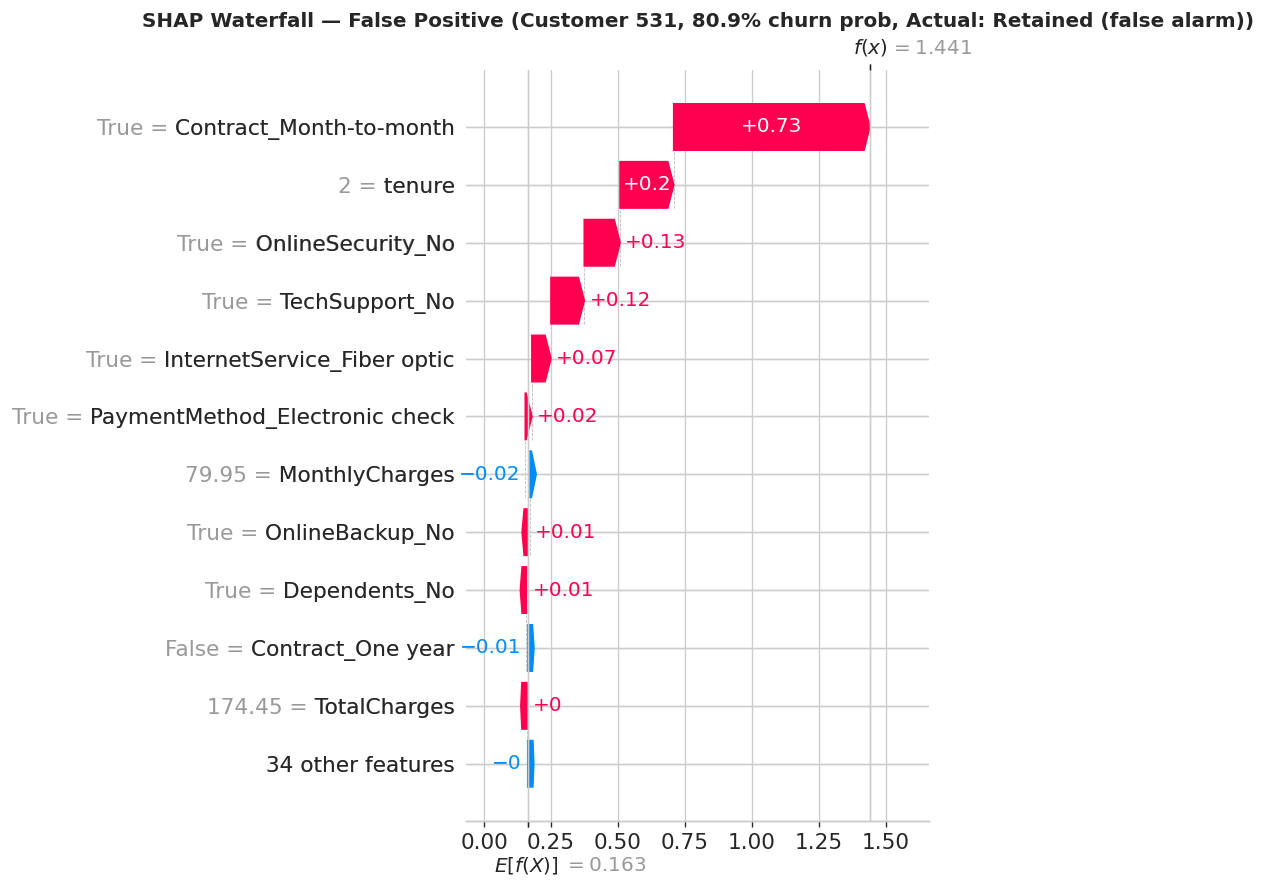

  False Positive (Customer 531):
  Predicted: 80.9% churn | Actual: Retained (false alarm)
  Top 5 churn-increasing: 
    Contract_Month-to-month                       +0.7331  value=True
    tenure                                        +0.2005  value=2
    OnlineSecurity_No                             +0.1338  value=True
    TechSupport_No                                +0.1245  value=True
    InternetService_Fiber optic                   +0.0712  value=True
  Top 5 churn-decreasing: 
    MonthlyCharges                                 -0.0181  value=79.95
    Contract_One year                              -0.0058  value=False
    TechSupport_Yes                                -0.0025  value=False
    OnlineSecurity_Yes                             -0.0015  value=False
    PaymentMethod_Bank transfer (automatic)        -0.0002  value=False


In [ ]:
# dependency: requires best_model from section 10 and explainer from section 11
# shap_values_ext is recomputed below if not already in scope
# find a representative false negative and false positive from the test set
y_pred_final_all = best_model.predict(X_test)
y_proba_final_all = best_model.predict_proba(X_test)[:, 1]

# false negatives: actual churner (y=1) predicted retained (yhat=0)
fn_mask = (y_test.values == 1) & (y_pred_final_all == 0)
fn_indices = np.where(fn_mask)[0]
# pick the most confident FN (lowest predicted probability among missed churners)
fn_proba_vals = y_proba_final_all[fn_mask]
fn_idx = fn_indices[fn_proba_vals.argmin()]
fn_proba = y_proba_final_all[fn_idx]

# false positives: actual retained (y=0) predicted churner (yhat=1)
fp_mask = (y_test.values == 0) & (y_pred_final_all == 1)
fp_indices = np.where(fp_mask)[0]
# pick the most confident FP (highest predicted probability among false alarms)
fp_proba_vals = y_proba_final_all[fp_mask]
fp_idx = fp_indices[fp_proba_vals.argmax()]
fp_proba = y_proba_final_all[fp_idx]

print(f'Total false negatives: {fn_mask.sum()} | Total false positives: {fp_mask.sum()}')
print(f'Selected FN: test index {fn_idx}, predicted churn prob={fn_proba*100:.1f}%, actual=Churned')
print(f'Selected FP: test index {fp_idx}, predicted churn prob={fp_proba*100:.1f}%, actual=Retained')
# store for diagnostic cell
fn_index = int(fn_idx)
fp_index = int(fp_idx)

# recompute shap values if not in scope
shap_values_ext = explainer.shap_values(X_test)

for label, idx, proba, actual in [
    ('False Negative', fn_idx, fn_proba, 'Churned (missed)'),
    ('False Positive', fp_idx, fp_proba, 'Retained (false alarm)')
]:
    shap_exp = shap.Explanation(
        values=shap_values_ext[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist()
    )
    plt.figure(figsize=(12, 7))
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {label} (Customer {X_test.index[idx]}, {proba*100:.1f}% churn prob, Actual: {actual})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = f'shap_waterfall_{label.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    # print top drivers
    shap_series = pd.Series(shap_values_ext[idx], index=X_test.columns)
    print(f'  {label} (Customer {X_test.index[idx]}):')
    print(f'  Predicted: {proba*100:.1f}% churn | Actual: {actual}')
    print(f'  Top 5 churn-increasing: ')
    for feat, val in shap_series.nlargest(5).items():
        print(f'    {feat:<45s} +{val:.4f}  value={X_test.iloc[idx][feat]}')
    print(f'  Top 5 churn-decreasing: ')
    for feat, val in shap_series.nsmallest(5).items():
        print(f'    {feat:<45s}  {val:.4f}  value={X_test.iloc[idx][feat]}')


### 14.3 scale_pos_weight Baseline

A structural concern with the GridSearchCV approach is that tuning on SMOTE-ENN resampled folds produces CV recall materially higher than recall on the natural test distribution. This gap indicates the model calibrated to a near-balanced synthetic distribution rather than the real 1:2.76 ratio.

An alternative approach trains directly on the natural class distribution using XGBoost's `scale_pos_weight` parameter, which upweights minority class errors during gradient computation without generating synthetic samples. This eliminates the train/test distribution mismatch entirely.

`scale_pos_weight` = majority count / minority count in the training set ≈ **2.763**, matching the natural class ratio preserved by the stratified split.

#### Interpretation

The `scale_pos_weight` model achieves recall above the 77% target but below SMOTE-ENN. On every metric it is marginally weaker than the SMOTE-ENN baseline. It is not the better model.

However, the CV gap result is the important finding here. SMOTE-ENN's CV-to-test recall gap (96.27% to 81.28%, a 14.99pp drop) is substantially larger than the `scale_pos_weight` model's gap (81.65% to 79.14%, a 2.51pp drop). The result directly confirms that the SMOTE-ENN CV gap is a distributional artefact of evaluating on resampled folds rather than the natural 1:2.76 test distribution. The `scale_pos_weight` model trains and evaluates on the natural distribution throughout, so its CV score is an honest estimate.

The SMOTE-ENN model remains valid and its test recall is real and verified. The finding does mean the SMOTE-ENN CV recall figure should not be cited as a performance claim; the test recall is the operationally honest number, as stated in the CV score caveat in Section 10.

> **Deployment implication:** If distributional honesty in CV reporting is a hard requirement (e.g., for a production monitoring system), `scale_pos_weight` is the more trustworthy configuration despite its marginally lower test recall.


In [ ]:
# scale_pos_weight experiment: train on natural distribution, no synthetic samples
spw = round((y_train == 0).sum() / (y_train == 1).sum(), 4)
print(f'scale_pos_weight = {spw} (majority/minority = {(y_train==0).sum()}/{(y_train==1).sum()})')

param_grid_spw = {
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth':     [3, 4, 5, 6, 7],
    'n_estimators':  [50, 100, 200, 300, 500]
}
cv_spw = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Running recall-tuned GridSearchCV with scale_pos_weight (no resampling)...')
gs_spw = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=spw,
        random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False
    ),
    param_grid_spw, scoring='recall', cv=cv_spw, n_jobs=-1, verbose=0
)
gs_spw.fit(X_train, y_train)
best_model_spw = gs_spw.best_estimator_

y_pred_spw   = best_model_spw.predict(X_test)
y_proba_spw  = best_model_spw.predict_proba(X_test)[:, 1]

spw_metrics = {
    'accuracy':  round(float(accuracy_score(y_test, y_pred_spw)) * 100, 2),
    'precision': round(float(precision_score(y_test, y_pred_spw)) * 100, 2),
    'recall':    round(float(recall_score(y_test, y_pred_spw)) * 100, 2),
    'f1':        round(float(f1_score(y_test, y_pred_spw)) * 100, 2),
    'auc':       round(float(roc_auc_score(y_test, y_proba_spw)), 4)
}
print(f'Best params (SPW): {gs_spw.best_params_}')
print(f'Best CV recall (SPW): {gs_spw.best_score_*100:.2f}%')
print(f'scale_pos_weight model — Acc: {spw_metrics["accuracy"]}% | Prec: {spw_metrics["precision"]}% | '
      f'Recall: {spw_metrics["recall"]}% | F1: {spw_metrics["f1"]}% | AUC: {spw_metrics["auc"]}')
print(f'SMOTE-ENN model (ref) — Acc: {final_metrics["accuracy"]}% | Prec: {final_metrics["precision"]}% | '
      f'Recall: {final_metrics["recall"]}% | F1: {final_metrics["f1"]}% | AUC: {final_metrics["auc"]}')
print(f'Delta recall: {spw_metrics["recall"] - final_metrics["recall"]:+.2f}pp | '
      f'Delta precision: {spw_metrics["precision"] - final_metrics["precision"]:+.2f}pp')


scale_pos_weight = 2.763 (majority/minority = 3614/1308)
Running recall-tuned GridSearchCV with scale_pos_weight (no resampling)...
Best params (SPW): {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best CV recall (SPW): 81.65%
scale_pos_weight model — Acc: 72.56% | Prec: 49.01% | Recall: 79.14% | F1: 60.53% | AUC: 0.8253
SMOTE-ENN model (ref) — Acc: 74.55% | Prec: 51.35% | Recall: 81.28% | F1: 62.94% | AUC: 0.8263
Delta recall: -2.14pp | Delta precision: -2.34pp


## Section 15: Summary

> **Note:** The XGBoost + SMOTE model (Section 8) is excluded from this table; it is an exploratory intervention where three variables change simultaneously and is not part of the controlled pipeline progression. See the Section 8 scope note and the Section 13 consolidated table.

| Model | Threshold | Accuracy | Precision | Recall | F1 | AUC |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| LR Baseline | 0.41 | 79.15% | 59.50% | 67.56% | 63.27% | 0.8377 |
| XGBoost -- No Resampling | 0.50 | 77.63% | 58.99% | 52.05% | 55.30% | 0.8120 |
| SMOTE-ENN + XGBoost (default) | 0.50 | 75.97% | 53.71% | 69.70% | 60.67% | 0.8200 |
| SMOTE-ENN + XGBoost (F1-tuned) | 0.50 | 75.88% | 53.64% | 68.27% | 60.08% | 0.8172 |
| **SMOTE-ENN + XGBoost (Recall-tuned)** | **0.50** | **74.55%** | **51.35%** | **81.28%** | **62.94%** | **0.8263** |

### Final Model

| Model | Resampling | Best Params | Threshold ($\tau$) | Accuracy | Precision | Recall | F1 | AUC |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| SMOTE-ENN + XGBoost (Recall-tuned) | SMOTE-ENN (4,074 x 45) | $\text{lr}=0.01$, $\text{depth}=3$, $n=100$ | 0.50 | 74.55% | 51.35% | 81.28% | 62.94% | 0.8263 |

### Conclusion

**Resampling strategy matters more than architecture.** The untuned SMOTE-ENN model (69.70% recall) already outperforms both the LR baseline (67.56%) and XGBoost with no resampling (52.05%), purely from the boundary-cleaning effect of ENN applied after SMOTE interpolation.

**Recall-tuned GridSearchCV produces a qualitatively different model.** F1-tuned search returned parameters close to the default with marginal gains; recall-tuned search found a low learning rate, shallow tree configuration ($\text{lr}=0.01$, $\text{depth}=3$, $n=100$) that raised recall by 11.58pp over the SMOTE-ENN default (Section 9) at a precision cost of 2.36pp; a rational trade-off under the asymmetric cost framework. The final model achieves 81.28% recall at $\tau = 0.50$, exceeding the 77% target by 4.28pp without any threshold adjustment beyond the default.

**Contract type dominates all other signals.** `Contract_Month-to-month` has a mean |SHAP| of 0.7143, nearly three times the next feature (`tenure` at 0.2538). Retention interventions should prioritise contract upgrade offers above all other actions.

**Feature engineering was rejected.** Three SHAP-derived interaction features (`charge_per_tenure`, `service_count`, `has_any_addon`) reduced recall by 12.12pp with no offsetting benefit, confirming XGBoost already resolves these interactions natively through its split mechanism.

**The SMOTE-ENN CV recall gap (96.27% to 81.28%, a 14.99pp drop) is a distributional artefact**, not a model quality issue. The `scale_pos_weight` baseline trained on the natural distribution throughout produced a much smaller gap (81.65% to 79.14%, a 2.51pp drop), directly confirming the diagnosis. SMOTE-ENN remains the superior configuration on test recall (81.28% vs 79.14%).

## References

| # | Citation | Link |
| :--- | :--- | :--- |
| <sup>[1]</sup> | IBM Telco Customer Churn Dataset. *Kaggle*, 2019. | [🔗](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) |
| <sup>[2]</sup> | Bhat, N. (2020). *Outlier: The Silent Killer*. Kaggle. | [🔗](https://www.kaggle.com/code/nareshbhat/outlier-the-silent-killer) |
| <sup>[3]</sup> | Rahman, F. (2018). *Telco Customer Churn — Logistic Regression*. Kaggle. | [🔗](https://www.kaggle.com/code/farazrahman/telco-customer-churn-logisticregression) |
| <sup>[4]</sup> | Bandiatindra (2018). *Telecom Churn Prediction*. Kaggle. | [🔗](https://www.kaggle.com/code/bandiatindra/telecom-churn-prediction) |
| <sup>[5]</sup> | Tanmay111999 (2023). *Telco Churn: EDA, CV Score 85%, F1 Score 80%*. Kaggle. | [🔗](https://www.kaggle.com/code/tanmay111999/telco-churn-eda-cv-score-85-f1-score-80) |
| <sup>[6]</sup> | Prasad, B. (2020). *Customer Churn Prediction*. Kaggle. | [🔗](https://www.kaggle.com/code/bhartiprasad17/customer-churn-prediction) |
| <sup>[7]</sup> | Gallo, A. (2014). The Value of Keeping the Right Customers. *Harvard Business Review*. | [🔗](https://hbr.org/2014/10/the-value-of-keeping-the-right-customers) |
| <sup>[8]</sup> | Liu, Y., & Zhuang, L. (2015). Application of Machine Learning in Customer Churn Prediction. *Scientific Research Publishing*. | [🔗](https://www.scirp.org/journal/PaperInformation.aspx?PaperID=56907) |
| <sup>[9]</sup> | Verbeke, W., Dejaeger, K., Martens, D., Hur, J., & Baesens, B. (2012). New insights into churn prediction in the telecommunication sector: A profit driven data mining approach. *European Journal of Operational Research, 218*(1), 211–229. | [🔗](https://ideas.repec.org/a/eee/ejores/v218y2012i1p211-229.html) |
| <sup>[10]</sup> | Verbraken, T., Verbeke, W., & Baesens, B. (2013). A Novel Profit Maximizing Metric for Measuring Classification Performance of Customer Churn Prediction Models. *IEEE Transactions on Knowledge and Data Engineering, 25*(5). | [🔗](https://ieeexplore.ieee.org/document/6165289/) |
| <sup>[11]</sup> | Chang, V., et al. (2024). Customer Churn Prediction Using Machine Learning. *MDPI Algorithms, 17*(6), 231. | [🔗](https://www.mdpi.com/1999-4893/17/6/231) |
| <sup>[12]</sup> | Chawla, N. V., Bowyer, K. W., Hall, L. O., and Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research, 16*, 321–357. | [🔗](https://doi.org/10.1613/jair.953) |
| <sup>[13]</sup> | Alvarez-Melis, D. and Jaakkola, T. S. (2018). On the Robustness of Interpretability Methods. *ICML Workshop on Human Interpretability in Machine Learning*. | [🔗](https://arxiv.org/abs/1806.08049) |
| <sup>[14]</sup> | Lundberg, S. M. and Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *Advances in Neural Information Processing Systems, 30*. | [🔗](https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html) |
| <sup>[15]</sup> | Wilson, D. L. (1972). Asymptotic properties of nearest neighbor rules using edited data. *IEEE Transactions on Systems, Man, and Cybernetics, SMC-2*(3), 408–421. | [🔗](https://doi.org/10.1109/TSMC.1972.4309137) |

---

## Acknowledgements

Claude was used for research, code debugging, error diagnosis, and markdown formatting assistance only. All analytical decisions, model design, and written interpretation are the author's own.
